#**유통 판매량 예측 및 재고 최적화**
## **단계1 : 데이터 탐색 및 가설 도출**

# **0.미션**

* 예측해야 할 핵심상품 역할 분담
    * 핵심상품 별로, 데이터 탐색, 가설수립, 데이터셋 구성
    * 1인당 1~2개 정도를 분담하여 개별 과제 수행
    * 팀 미팅을 통해 진행 사항 공유 및 취합

* 데이터 탐색 및 가설 도출
    * 주어진 데이터에 대해 대상 매장, 대상 상품의 그래프 그리고 시계열 패턴을 찾기
    * 찾은 패턴을 기반으로 가설 도출

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|2|6|
|42|FM001|Agricultural products|Grocery|2|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
path = '/content/drive/MyDrive/project6/'

### **(2) 라이브러리 설치 및 불러오기**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

In [5]:
def print_bold(s=None, end='\n'):
    print(f"\033[1m{s}\033[0m", end=end)

### **(3) 데이터 불러오기**

#### 1) 데이터로딩

In [ ]:
# import zipfile
# zipfile.ZipFile(path+'/train.zip').extractall('/content/train')
# zipfile.ZipFile(path+'/test.zip').extractall('/content/test')

In [13]:
# path = '/content/'

oil_price = pd.read_csv(path + 'train/oil_price_train.csv')
orders = pd.read_csv(path + 'train/orders_train.csv')
sales = pd.read_csv(path + 'train/sales_train.csv')
products = pd.read_csv(path + 'train/products.csv')
stores = pd.read_csv(path + 'train/stores.csv')

sales['Date'] = pd.to_datetime(sales['Date'] )
oil_price['Date'] = pd.to_datetime(oil_price['Date'] )
orders['Date'] = pd.to_datetime(orders['Date'] )

In [ ]:
data = sales.merge(orders, on = ['Date', 'Store_ID'], how = 'left')
data_3 = data[(data['Store_ID']==44)&(data['Product_ID'] == 3)]
data_3 = data_3.drop(columns=['Store_ID']).reset_index(drop = True)

data_12 = data[(data['Store_ID']==44)&(data['Product_ID'] == 12)]
data_12 = data_12.drop(columns=['Store_ID']).reset_index(drop = True)

data_42 = data[(data['Store_ID']==44)&(data['Product_ID'] == 42)]
data_42 = data_42.drop(columns=['Store_ID']).reset_index(drop = True)

#### 2) 기본 정보 조회

In [14]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_ID    16 non-null     int64 
 1   Product_Code  16 non-null     object
 2   SubCategory   16 non-null     object
 3   Category      16 non-null     object
 4   LeadTime      16 non-null     int64 
 5   Price         16 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 896.0+ bytes


In [15]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Store_ID    54 non-null     int64 
 1   City        54 non-null     object
 2   State       54 non-null     object
 3   Store_Type  54 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.8+ KB


In [16]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57558 entries, 0 to 57557
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           57558 non-null  datetime64[ns]
 1   Store_ID       57558 non-null  int64         
 2   CustomerCount  57558 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.3 MB


In [17]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934275 entries, 0 to 934274
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Date        934275 non-null  datetime64[ns]
 1   Store_ID    934275 non-null  int64         
 2   Qty         934275 non-null  float64       
 3   Product_ID  934275 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 28.5 MB


# **2.데이터 탐색**

* 시계열 패턴을 찾아보기 위한 그래프를 그려 봅시다.

## **(1) 시계열 패턴 찾아보기1**

* 다음 항목은 패턴을 찾기 위한 예제 문항 입니다. 참조하여 시계열 패턴을 찾아 봅시다.
    * 대상 매장(44), 대상 상품(3,12,42)의 판매량 추이
    * 대상 상품의 동일 카테고리의 상품별 판매량 추이
    * 휘발유 가격과 상품 판매량 추이 비교
    * 방문 고객수와 상품 판매량 추이 비교
    * 그외...

### 1) 대상 매장(44), 대상 상품의 판매량 추이

In [18]:
# 상품 ID, 시작날짜, 마지막날짜 입력 시 그래프 출력

def show_sales_trend(Product_ID, sdate=None, edate=None) :
    # 날짜 미입력 시
    if sdate is None : sdate = sales['Date'].min()
    if edate is None : edate = sales['Date'].max()

    # 대상 매장(44)의 대상 상품(Product_ID) 판매량 저장
    df_sales_ = sales[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID)]
    df_sales_ = df_sales_[df_sales_['Date'].between(sdate, edate)].reset_index(drop=True)

    # 데이터 안에 존재하는 날짜로 변환
    sdate, edate = df_sales_['Date'].min(), df_sales_['Date'].max()

    # 판매량 평균 및 표준편차 저장
    mean = df_sales_['Qty'].mean()
    std = df_sales_['Qty'].std()

    # 시각화
    plt.figure(figsize=(12, 3))
    plt.plot(df_sales_['Date'], df_sales_['Qty'], linewidth=0.8, label='Qty')

    # 평균 및 표준편차
    plt.axhline(mean, color='r', linewidth=0.5, linestyle='--')
    plt.axhline(mean + std, color='g', linewidth=0.5, linestyle='--')
    plt.axhline(mean - std, color='g', linewidth=0.5, linestyle='--')
    plt.text(sdate,mean,s=f'mean={mean:.2f}')
    plt.text(sdate,mean+std,s=f'std={std:.2f}')

    plt.xlabel('Date')
    plt.ylabel('Qty')
    plt.legend()
    tmp_product_info = products[products['Product_ID'] == Product_ID].values[0]
    plt.title(f"[ID {tmp_product_info[0]}, {tmp_product_info[2]}] : Sales Graph ({sdate.date()} ~ {edate.date()})")
    plt.show()

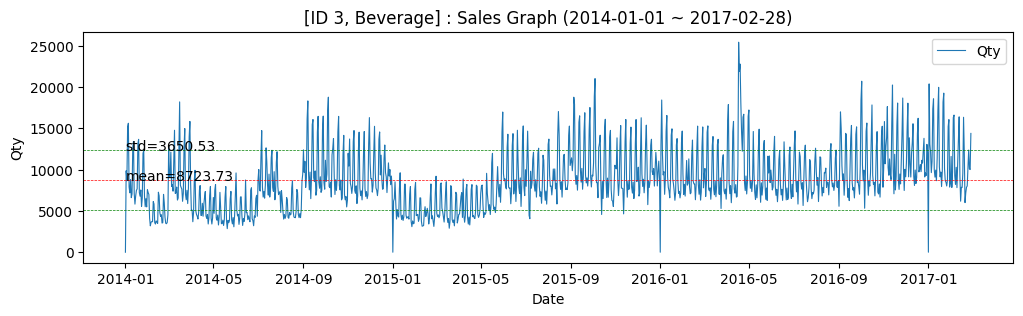

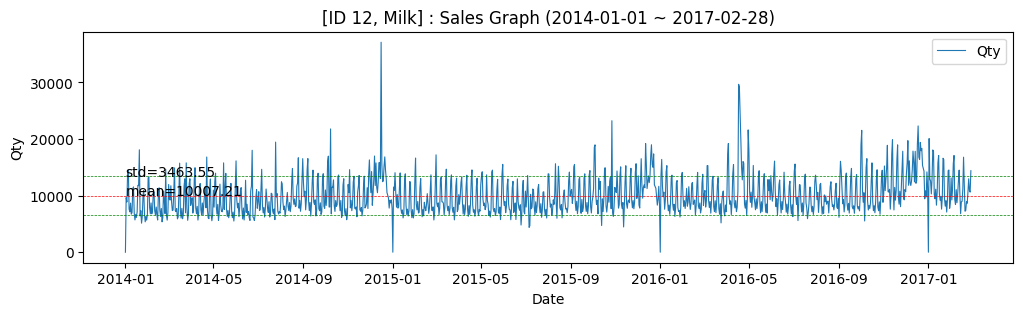

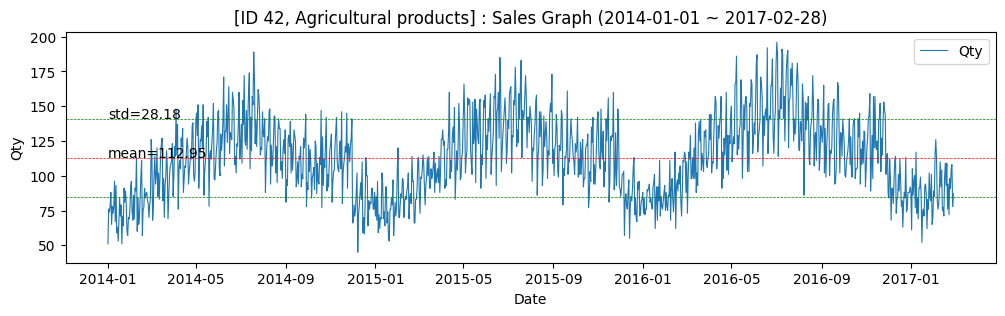

In [19]:
show_sales_trend(3)
show_sales_trend(12)
show_sales_trend(42)

첫 데이터 날짜: 2014-01-01 00:00:00
중간 데이터 날짜: 2015-08-02 00:00:00
마지막 데이터 날짜: 2017-02-28 00:00:00


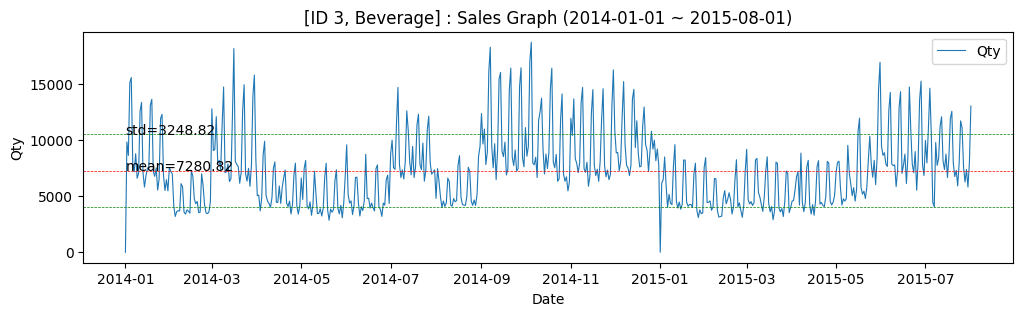

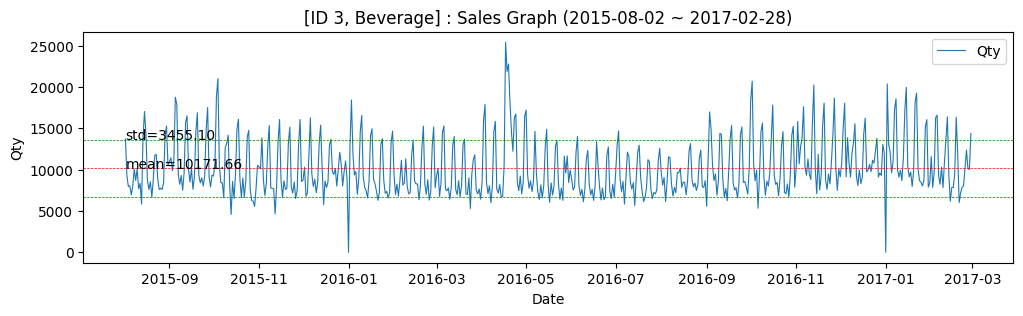

In [20]:
#### 대상 매장(44)의 대상 상품(3) 판매량 저장 ####
df_3 = sales[(sales['Store_ID'] == 44) & (sales['Product_ID'] == 3)]

# 대상 매장(44)의 대상 상품(3) 판매량 데이터 날짜 출력
print_bold('첫 데이터 날짜:', end=' ') # 2014-01-01
print(df_3['Date'].min())
print_bold('중간 데이터 날짜:', end=' ') # 2015-08-02
print(df_3['Date'].reset_index(drop=True).iloc[int(df_3.shape[0]/2+1)])
print_bold('마지막 데이터 날짜:', end=' ') # 2017-02-28
print(df_3['Date'].max())

# 전기, 후기 시각화
show_sales_trend(3,'2014-01-01', '2015-08-01')
show_sales_trend(3,'2015-08-02', '2017-02-28')

In [22]:
def show_sales_per_month(Product_ID):
  df_3 = sales[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID)]

  # 연도별, 월별 판매량 추이
  idx = df_3[df_3['Date'].between('2014-01-01', '2015-01-01', inclusive = 'left')].astype({'Date':'str'})['Date'].apply(lambda x: x[5:7]).values
  # 연도별, 일별 판매량 추이
  # idx = df_3[df_3['Date'].between('2014-01-01', '2015-01-01', inclusive = 'left')].astype({'Date':'str'})['Date'].apply(lambda x: x[8:]).values
  # 연도별, 월별, 일별 판매량 추이
  # idx = range(1,365)

  plt.figure(figsize = (15,5))
  sns.lineplot(x = idx, y = 'Qty', data = df_3[df_3['Date'].between('2014-01-01', '2015-01-01', inclusive = 'left')], label = '2014')
  sns.lineplot(x = idx, y = 'Qty', data = df_3[df_3['Date'].between('2015-01-01', '2016-01-01', inclusive = 'left')], label = '2015')
  sns.lineplot(x = idx, y = 'Qty', data = df_3[~(df_3['Date'] == '2016-02-29')][df_3[~(df_3['Date'] == '2016-02-29')]['Date'].between('2016-01-01', '2017-01-01', inclusive = 'left')], label = '2016')
  plt.xticks(rotation = 30)
  plt.legend()
  tmp_product_info = products[products['Product_ID'] == Product_ID].values[0]
  plt.title(f"[ID {tmp_product_info[0]}, {tmp_product_info[2]}] : Sales per Month Graph")
  plt.show()

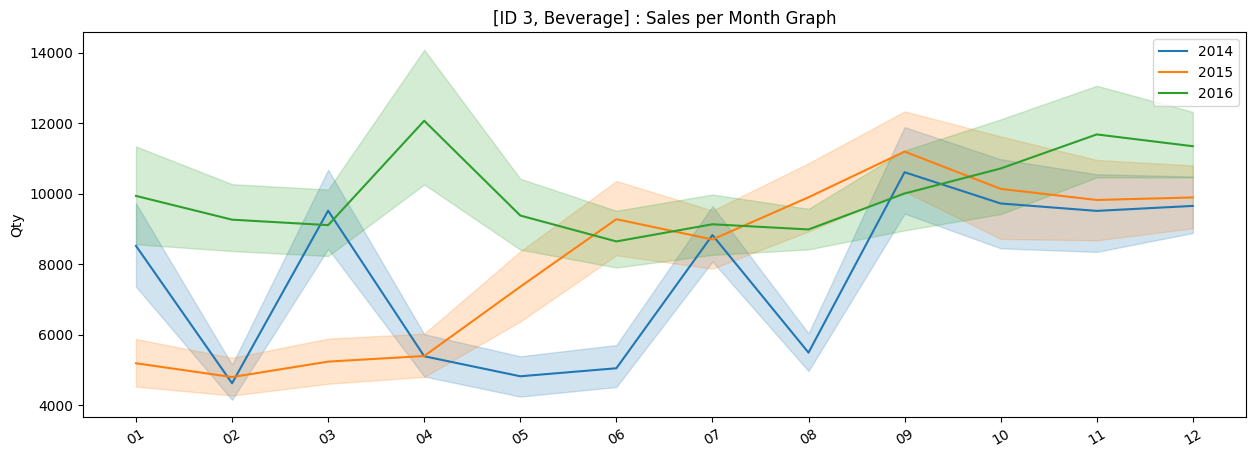

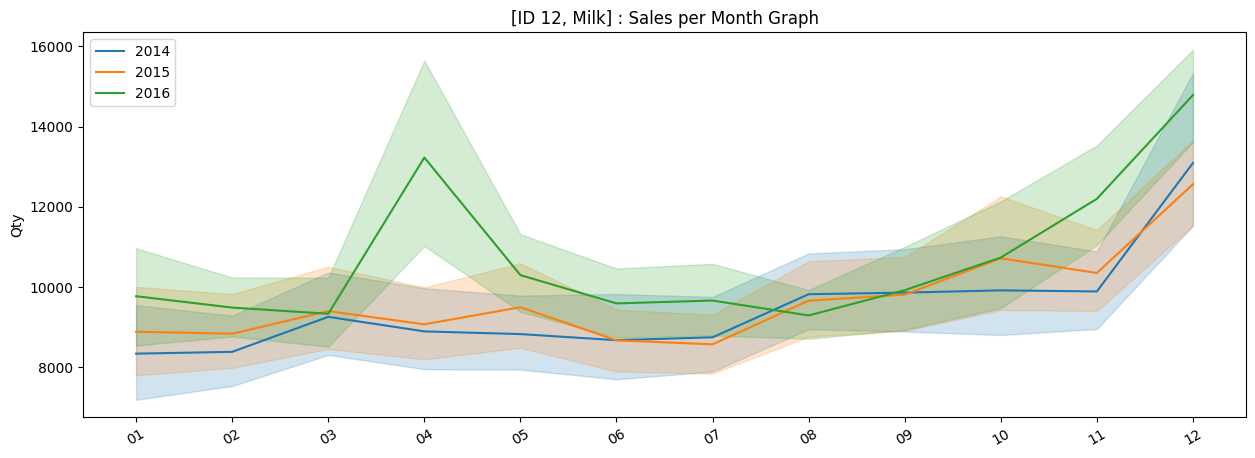

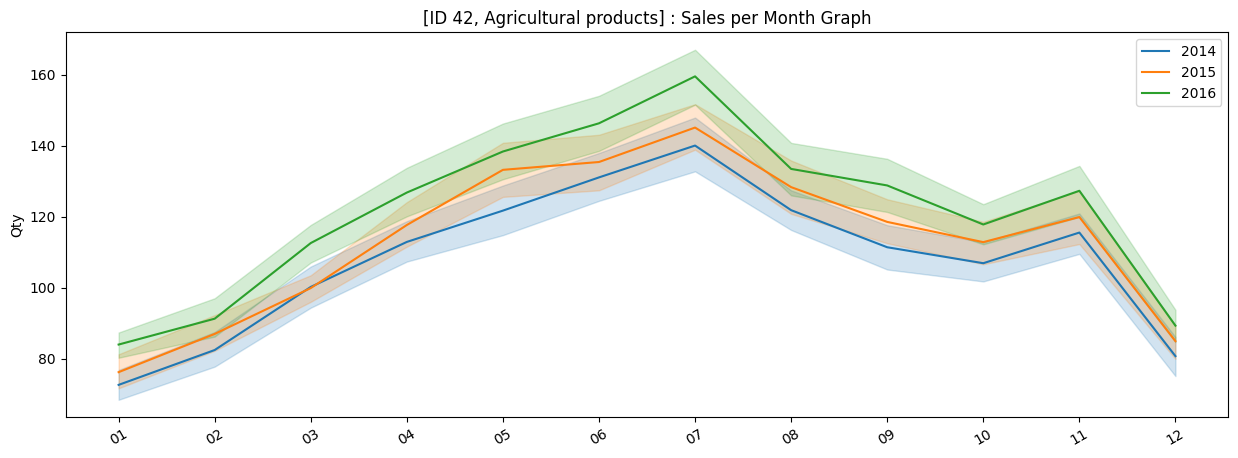

In [23]:
show_sales_per_month(3)
show_sales_per_month(12)
show_sales_per_month(42)

### 2) 대상 상품의 동일 카테고리의 상품별 판매량 추이

In [24]:
# 동일 카테고리 상품 추출 : Beverage(SubCategory), Drink(Category)
same_cate = products[products['Category'] == 'Drink'][['Product_ID','SubCategory','Category']]
print(f"===> 동일 카테고리(Drink) 상품 : Drink \n {same_cate}")
print()

same_cate = products[products['Category'] == 'Food'][['Product_ID','SubCategory','Category']]
print(f"===> 동일 카테고리(Drink) 상품 : Food \n {same_cate}")
print()

same_cate = products[products['Category'] == 'Grocery'][['Product_ID','SubCategory','Category']]
print(f"===> 동일 카테고리(Drink) 상품 : Grocery \n {same_cate}")
print()

===> 동일 카테고리(Drink) 상품 : Drink 
     Product_ID SubCategory Category
5           38        Wine    Drink
13           3    Beverage    Drink

===> 동일 카테고리(Drink) 상품 : Food 
     Product_ID SubCategory Category
6           29    Prepared     Food
7           11      Frozen     Food
10           5      BAKERY     Food
11           8      Yogurt     Food
14          12        Milk     Food

===> 동일 카테고리(Drink) 상품 : Grocery 
     Product_ID            SubCategory Category
4           32                Seafood  Grocery
8           10                   EGGS  Grocery
9           24                  Meats  Grocery
15          42  Agricultural products  Grocery



In [25]:
def show_sales_comparing(Product_ID, ID2, sdate=None, edate=None, standard=False) :
    # 날짜 미입력 시
    if sdate is None : sdate = sales['Date'].min()
    if edate is None : edate = sales['Date'].max()

    # 대상 매장(44)의 대상 상품(Product_ID) 판매량 및 비교대상(ID2) 데이터 저장
    df_sales_ = sales[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID)]
    df_sales_ = df_sales_[df_sales_['Date'].between(sdate, edate)]
    df_sales2_ = sales[(sales['Store_ID'] == 44) & (sales['Product_ID'] == ID2)]
    df_sales2_ = df_sales2_[df_sales2_['Date'].between(sdate, edate)]


    # 데이터 안에 존재하는 날짜로 변환
    sdate, edate = df_sales_['Date'].min(), df_sales_['Date'].max()

    # 표준화
    if standard:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        df_sales_['Qty'] = scaler.fit_transform(df_sales_['Qty'].values.reshape(-1,1))
        df_sales2_['Qty'] = scaler.fit_transform(df_sales2_['Qty'].values.reshape(-1,1))

    # 시각화
    plt.figure(figsize=(12, 3))
    plt.plot(df_sales_['Date'], df_sales_['Qty'], linewidth=0.8, label=f'Qty_{Product_ID}')
    plt.plot(df_sales2_['Date'], df_sales2_['Qty'], linewidth=0.8, label=f'Qty_{ID2}')
    plt.xlabel('Date')
    plt.ylabel('Qty')
    plt.legend()

    info1 = products[products['Product_ID'] == Product_ID].values[0]
    info2 = products[products['Product_ID'] == ID2].values[0]
    plt.title(f"[ID{info1[0]} {info1[2]}, ID{info2[0]} {info2[2]}] : Sales Graph ({sdate.date()} ~ {edate.date()})")

    plt.show()

In [26]:
id_drink = list(products[products['Category'] == 'Drink']['Product_ID'])
id_drink = [i for i in id_drink if i != 3]
id_food = list(products[products['Category'] == 'Food']['Product_ID'])
id_food = [i for i in id_food if i != 12]
id_grocery = list(products[products['Category'] == 'Grocery']['Product_ID'])
id_grocery = [i for i in id_grocery if i != 42]

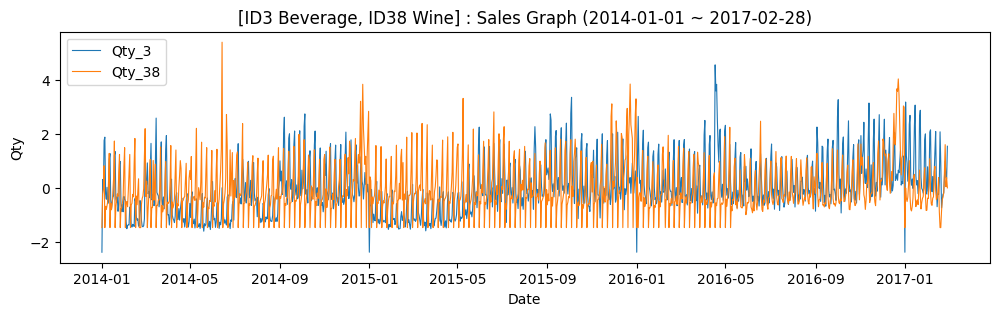

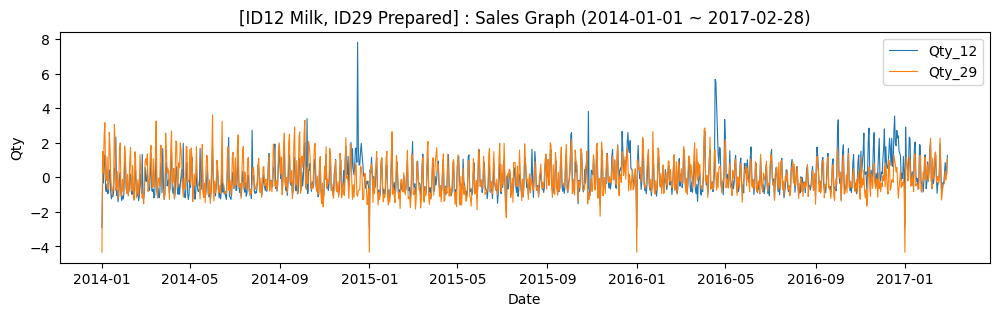

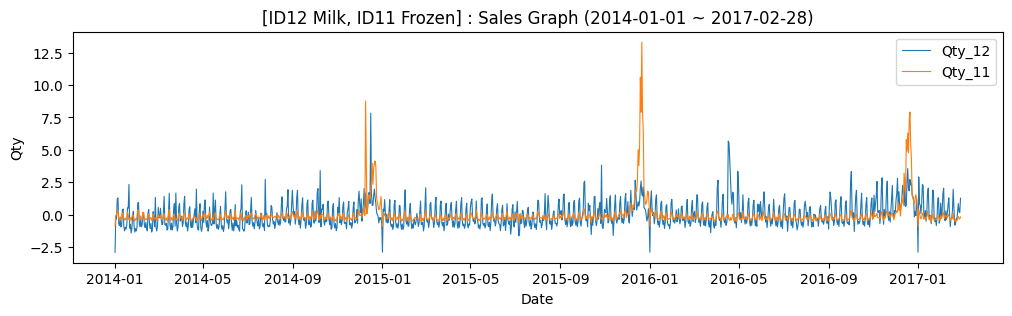

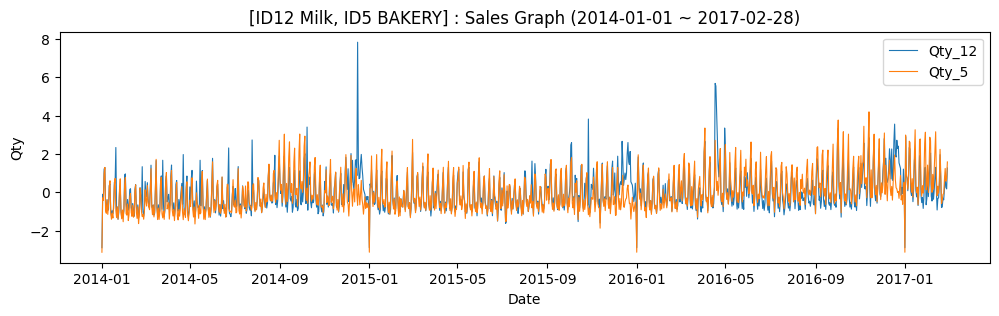

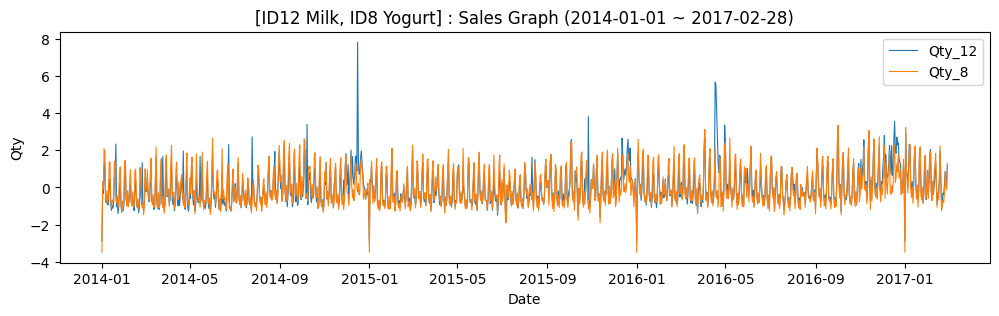

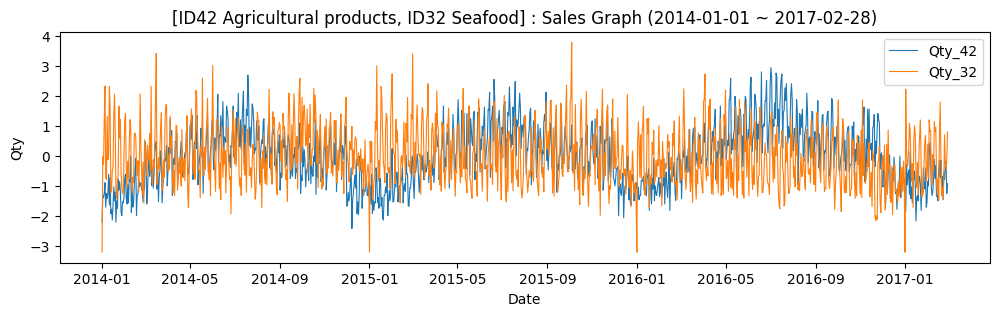

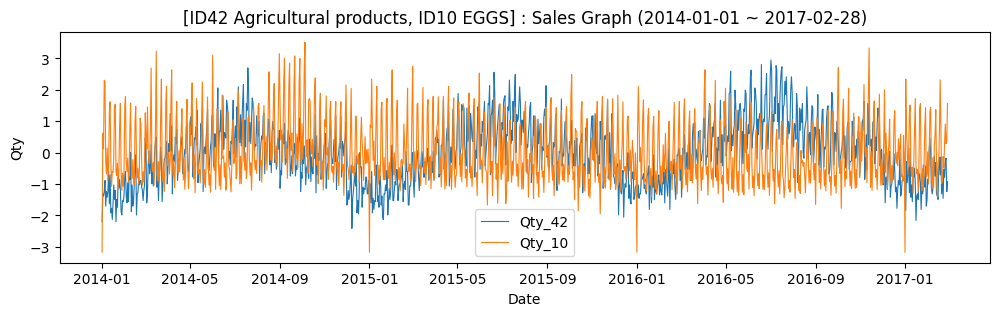

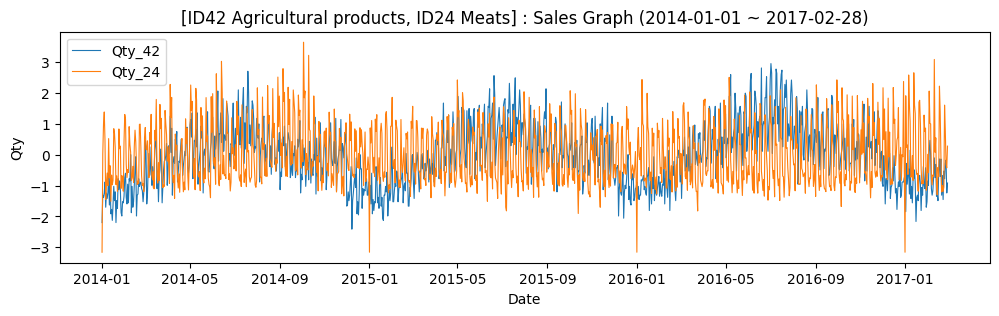

In [27]:
for product, category in zip([3,12,42],[id_drink, id_food, id_grocery]):
    for sub in category:
        show_sales_comparing(product, sub, standard=True)
    print("="*100)

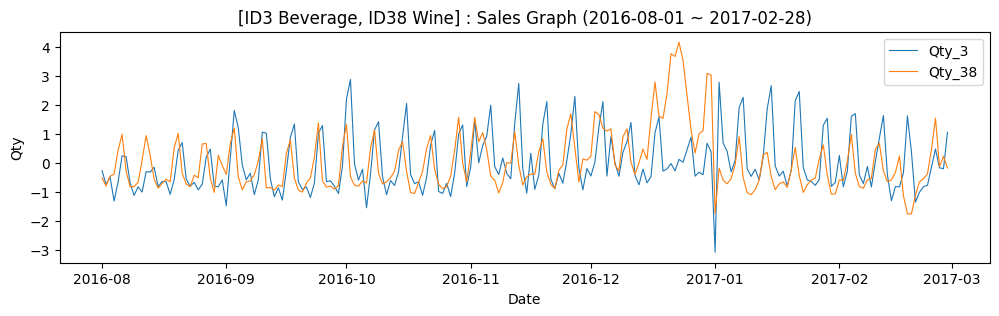

In [28]:
# 전기, 후기 기간
former_period = ['2014-01-01', '2015-08-01']
latter_period = ['2015-08-02', '2017-02-28']

# 시각화로 확인
# show_sales_comparing(3, 38, former_period[0], former_period[1], standard=True)
# show_sales_comparing(3, 38, latter_period[0], latter_period[1], standard=True)
show_sales_comparing(3, 38, '2016-08-01', latter_period[1], standard=True)


### 3) 휘발유 가격과 상품 판매량 추이 비교

In [45]:
def show_sales_n_oil(Product_ID, sdate=None, edate=None, standard=False) :
    # 날짜 미입력 시
    if sdate is None : sdate = sales['Date'].min()
    if edate is None : edate = sales['Date'].max()

    # 대상 매장(44)의 대상 상품(Product_ID) 판매량 및 유가 데이터 저장
    df_sales_ = sales[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID)]
    df_sales_ = df_sales_[df_sales_['Date'].between(sdate, edate)]
    df_oils_ = oil_price[oil_price['Date'].between(sdate, edate)]
    df_oils_['WTI_Price'] = df_oils_['WTI_Price'].fillna(method='bfill').fillna(method='ffill')


    # 데이터 안에 존재하는 날짜로 변환
    sdate, edate = df_sales_['Date'].min(), df_sales_['Date'].max()

    # 표준화
    if standard:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        df_sales_['Qty'] = scaler.fit_transform(df_sales_['Qty'].values.reshape(-1,1))
        df_oils_['WTI_Price'] = scaler.fit_transform(df_oils_['WTI_Price'].values.reshape(-1,1))

    # 시각화
    plt.figure(figsize=(12, 3))
    plt.plot(df_sales_['Date'], df_sales_['Qty'], linewidth=0.8, label=f'Qty_{Product_ID}')
    plt.plot(df_oils_['Date'], df_oils_['WTI_Price'], linewidth=0.8, label=f'WTI_Price')
    plt.xlabel('Date')
    plt.legend()

    info1 = products[products['Product_ID'] == Product_ID].values[0]
    plt.title(f"[ID{info1[0]} {info1[2]}] : Sales&Oil Price Graph ({sdate.date()} ~ {edate.date()})")

    plt.show()

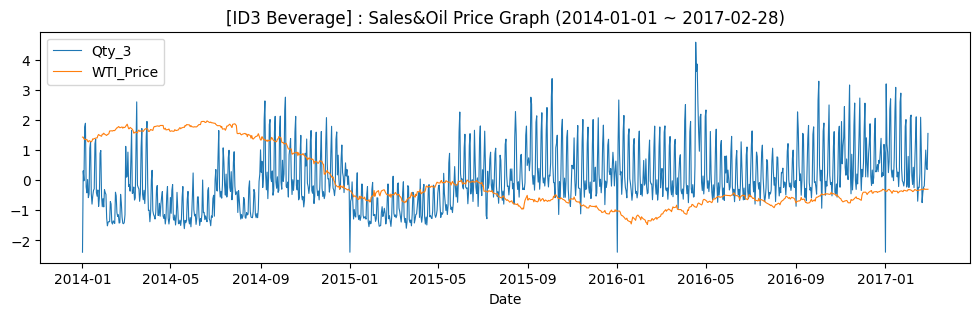

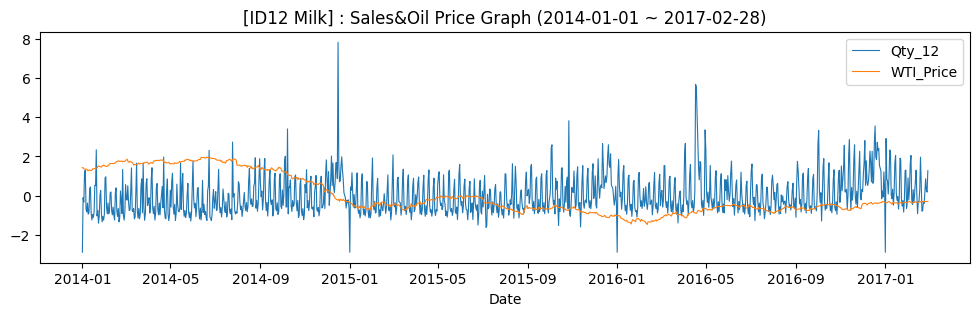

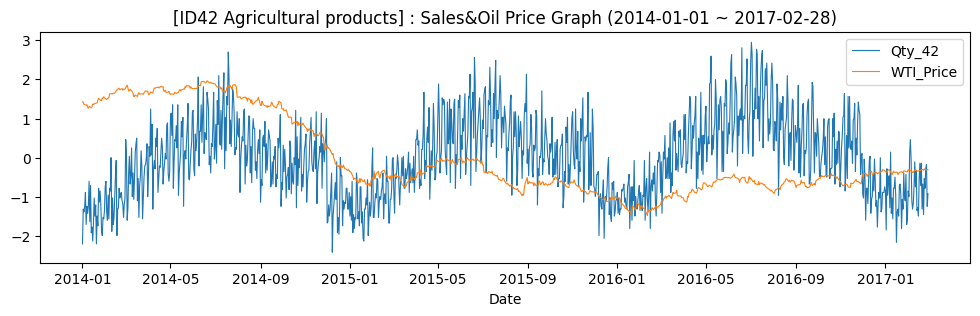

In [135]:
show_sales_n_oil(3, standard=True)
show_sales_n_oil(12, standard=True)
show_sales_n_oil(42, standard=True)

### 4) 방문 고객수와 상품 판매량 추이 비교

- 대상 매장(44)의 매장 고객 방문수 저장 및 출력
  - 판매량 데이터와 고객 수 데이터 개수가 다름
  
- df_3에만 존재하고 df_orders에는 없는 날짜 확인

- df_orders에 방문수 0인 날짜 있는지 확인
  - => 존재하지 않음

In [56]:
#### 대상 매장(44)의 매장 고객 방문수 저장 및 출력####
df_orders = orders[orders['Store_ID'] == 44].reset_index(drop=True)
print(df_3.shape, df_orders.shape, '\033[1m', ": 데이터 개수가 다름, 데이터 비교 시 주의",'\033[0m')

#### df_3와 df_orders에 겹치지 않는 날짜 출력 및 저장 ####
no_data_date = df_3[~df_3['Date'].isin(df_orders['Date'])]['Date']
print((pd.to_datetime(no_data_date.values)))

(1152, 4) (1146, 3)  : 데이터 개수가 다름, 데이터 비교 시 주의 
DatetimeIndex(['2014-01-01', '2015-01-01', '2016-01-01', '2016-01-03',
               '2016-01-04', '2017-01-01'],
              dtype='datetime64[ns]', freq=None)


In [57]:
def show_sales_n_customer(Product_ID, sdate=None, edate=None) :
    # 날짜 미입력 시
    if sdate is None : sdate = sales['Date'].min()
    if edate is None : edate = sales['Date'].max()

    # 대상 매장(44)의 대상 상품(Product_ID) 판매량 및 손님수 저장
    df_sales_ = sales[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID)]
    df_sales_ = df_sales_[df_sales_['Date'].between(sdate, edate)]
    df_orders_ = orders[(orders['Store_ID'] == 44) & (orders['Date'].between(sdate, edate))]

    # 데이터 안에 존재하는 날짜로 변환
    sdate, edate = df_sales_['Date'].min(), df_sales_['Date'].max()

    # 표준화
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df_sales_['Qty'] = scaler.fit_transform(df_sales_['Qty'].values.reshape(-1,1))
    df_orders_['CustomerCount'] = scaler.fit_transform(df_orders_['CustomerCount'].values.reshape(-1,1))

    # 시각화
    plt.figure(figsize=(12, 3))
    plt.plot(df_sales_['Date'], df_sales_['Qty'], linewidth=0.8, label='Qty')
    plt.plot(df_orders_['Date'], df_orders_['CustomerCount'], linewidth=0.8, label='CustomerCount')
    plt.xlabel('Date')
    plt.legend()

    tmp_product_info = products[products['Product_ID'] == Product_ID].values[0]
    plt.title(f"[ID {tmp_product_info[0]}, {tmp_product_info[2]}] : Sales&Customers Graph ({sdate.date()} ~ {edate.date()})")

    plt.show()

<Figure size 1200x300 with 0 Axes>

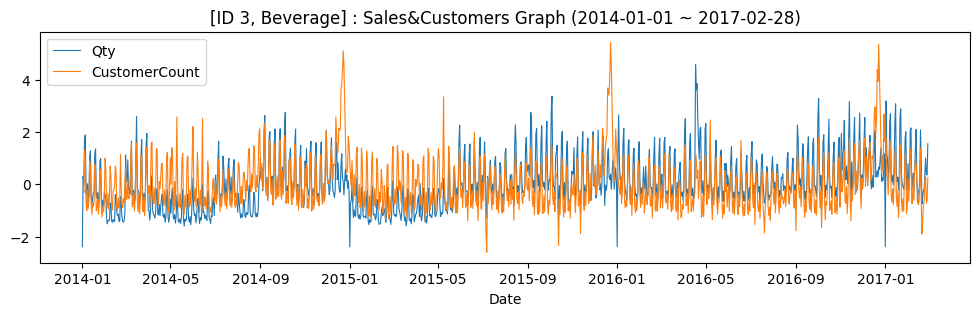

In [58]:
plt.figure(figsize=(12, 3))
show_sales_n_customer(3)

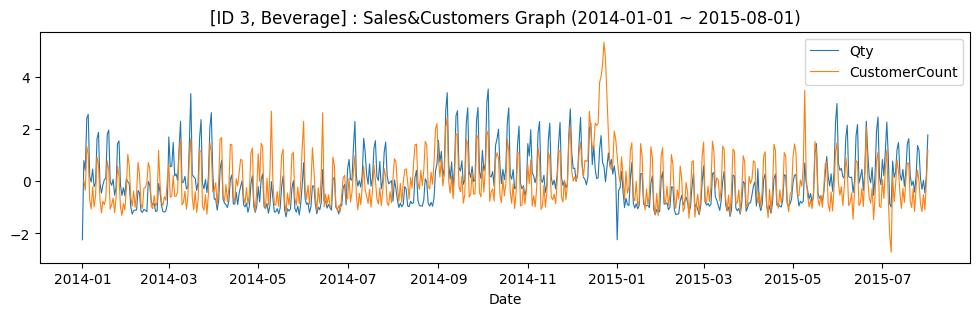

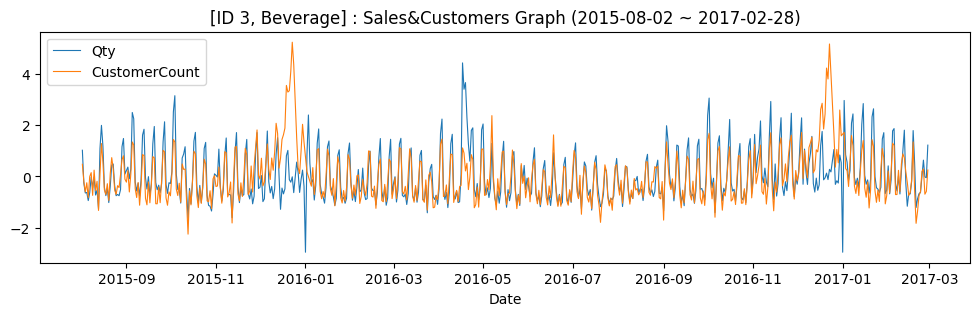

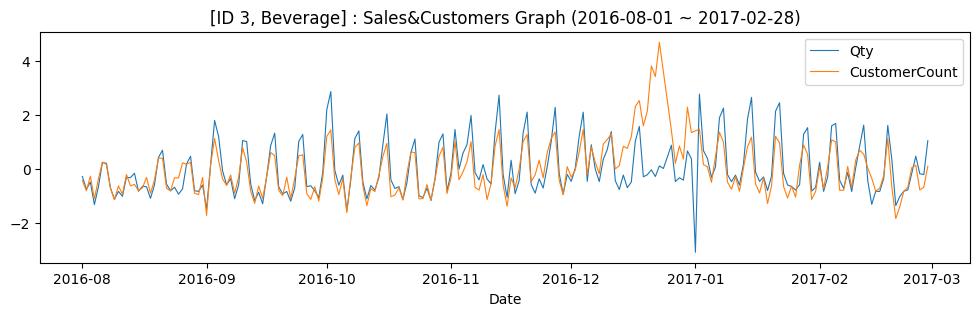

====> 상관관계가 강할 것으로 예상, 실제로 확인해볼 것


In [59]:
# 전기, 후기 기간
former_period = ['2014-01-01', '2015-08-01']
latter_period = ['2015-08-02', '2017-02-28']

# 시각화로 확인
show_sales_n_customer(3, former_period[0], former_period[1])
show_sales_n_customer(3, latter_period[0], latter_period[1])
show_sales_n_customer(3, '2016-08-01', latter_period[1])

# 결론
print_bold('====> 상관관계가 강할 것으로 예상, 실제로 확인해볼 것')

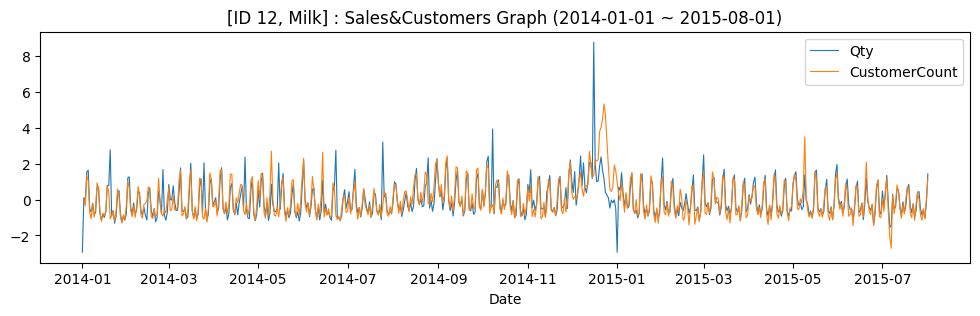

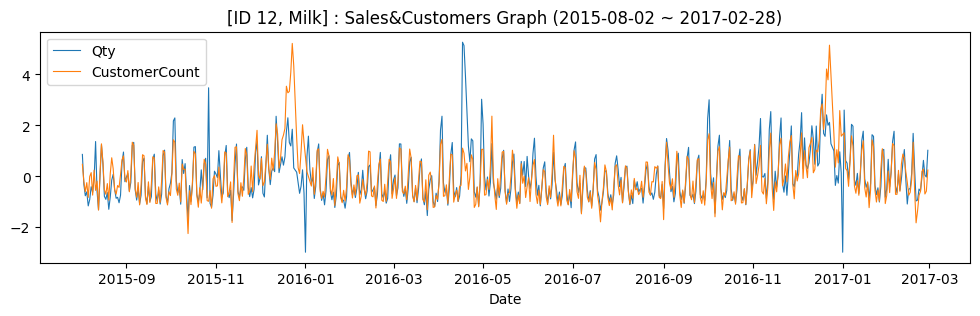

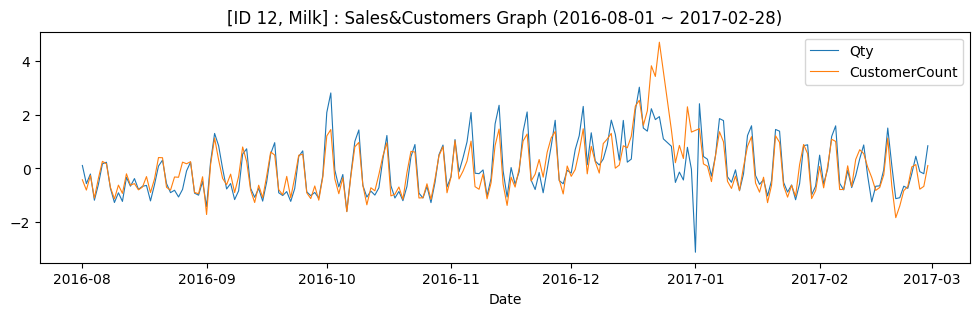

In [62]:
# 시각화로 확인
show_sales_n_customer(12, former_period[0], former_period[1])
show_sales_n_customer(12, latter_period[0], latter_period[1])
show_sales_n_customer(12, '2016-08-01', latter_period[1])

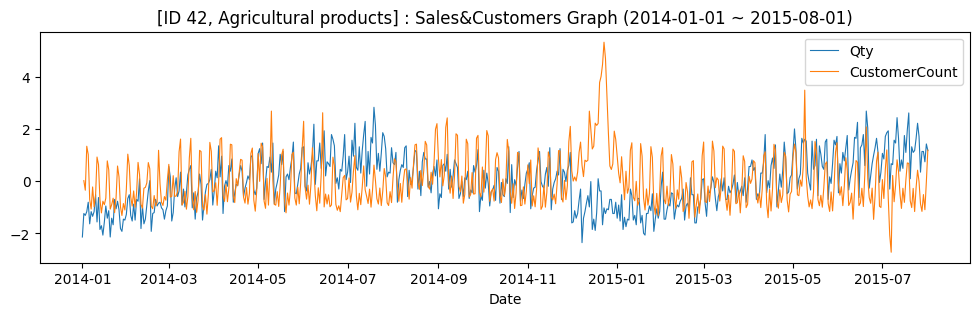

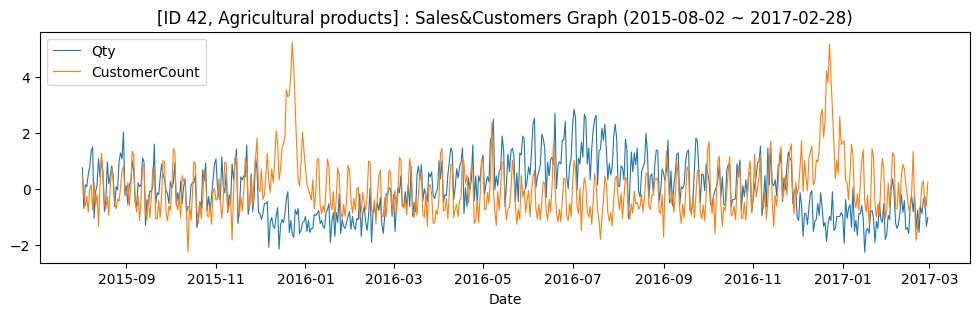

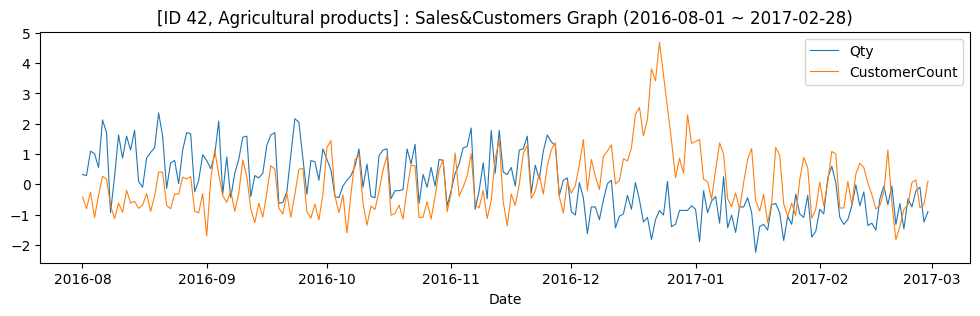

In [63]:
# 시각화로 확인
show_sales_n_customer(42, former_period[0], former_period[1])
show_sales_n_customer(42, latter_period[0], latter_period[1])
show_sales_n_customer(42, '2016-08-01', latter_period[1])

In [106]:
df_3.isna().sum()

,0
Date,0
Store_ID,0
Qty,0
Product_ID,0


[ID3]
공분산: 0.5904324318137292
상관계수: [statics] 0.5899172202676437 [p-value] 2.2380623182627903e-108


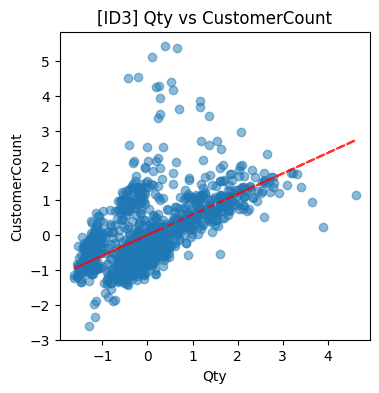

[ID12]
공분산: 0.7414186401747493
상관계수: [statics] 0.7407716780105479 [p-value] 6.812615543698194e-200


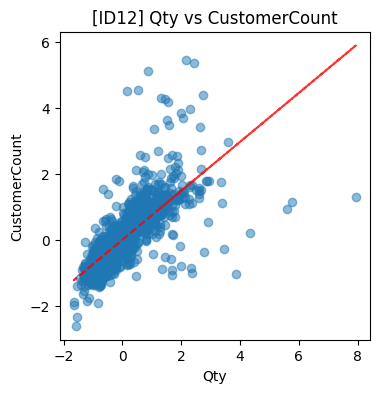

[ID42]
공분산: 0.09218351076839328
상관계수: [statics] 0.09210307140472104 [p-value] 0.0018013770066155725


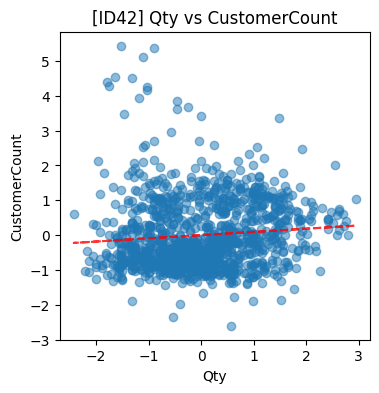

In [113]:
# 판매량, 고객수 상관관계 확인하기
from sklearn.preprocessing import StandardScaler
import numpy as np

def show_sales_n_customer_corr(Product_ID, sdate=None, edate=None) :
    # 날짜 미입력시
    if sdate is None : sdate = sales['Date'].min()
    if edate is None : edate = sales['Date'].max()

    # 데이터 가져오기
    df = sales.merge(orders, on = ['Date', 'Store_ID'], how = 'left')
    df = df[(df['Store_ID']==44)&(df['Product_ID'] == Product_ID)]
    df = df.drop(columns=['Store_ID']).reset_index(drop = True)
    df = df[df['Date'].between(sdate, edate)]

    # null값 정리
    df.dropna(inplace=True)

    # 데이터 속 존재하는 날짜로 업데이트
    sdate = df['Date'].min()
    edate = df['Date'].max()

    # 판매량, 고객수 추출
    qty = df['Qty']
    customers = df['CustomerCount']

    # 표준화
    scaler = StandardScaler()
    qty = scaler.fit_transform(qty.values.reshape(-1,1)).reshape(-1)
    customers = scaler.fit_transform(customers.values.reshape(-1,1)).reshape(-1)

    # 상관관계
    print_bold(f'[ID{Product_ID}]')
    print_bold("공분산:", end=' ')
    print(np.cov(qty, customers)[0,1])
    import scipy.stats as stats
    print_bold("상관계수:", end=' ')
    print('[statics]',stats.pearsonr(qty,customers)[0], '[p-value]',stats.pearsonr(qty,customers)[1])

    # 시각화
    plt.figure(figsize=(4,4))

    plt.scatter(qty, customers, alpha=0.5)
    plt.xlabel('Qty')
    plt.ylabel('CustomerCount')
    plt.title(f'[ID{Product_ID}] Qty vs CustomerCount')

    z = np.polyfit(qty, customers, 1)
    p = np.poly1d(z)
    plt.plot(qty, p(qty), "r--", alpha=0.8)
    plt.show()


show_sales_n_customer_corr(3)
show_sales_n_customer_corr(12)
show_sales_n_customer_corr(42)

## **(2) 시계열 패턴 찾아보기2**

* 변화량과 비교해보기

### 1) 대상 매장(44), 대상 상품의 판매량 추이

In [74]:
def sales_trends_prod2(Product_ID, sdate, edate):
    display( products.loc[products['Product_ID'].isin([Product_ID])])
    temp = sales.loc[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID) & (sales['Date'].between(sdate, edate))]
    temp['Qty_diff'] = temp['Qty'].diff()

    plt.figure(figsize = (12,4))
    plt.subplot(1,2,1)
    sns.lineplot(x='Date', y = 'Qty_diff', data = temp)
    plt.grid()
    plt.subplot(1,2,2)
    sns.histplot(x = 'Qty_diff', data = temp, bins = 20)
    plt.grid()
    plt.show()

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
13,3,DB001,Beverage,Drink,2,8


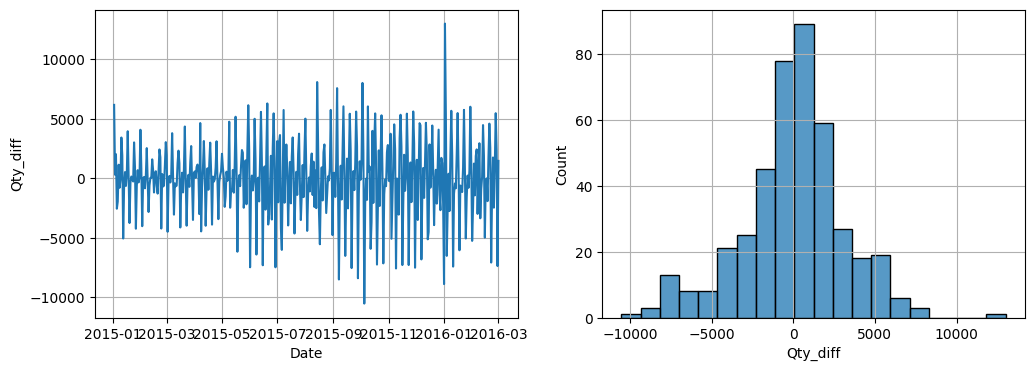

In [75]:
sales_trends_prod2(3, '2015-01-01', '2016-03-01')

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
14,12,GA001,Milk,Food,2,6


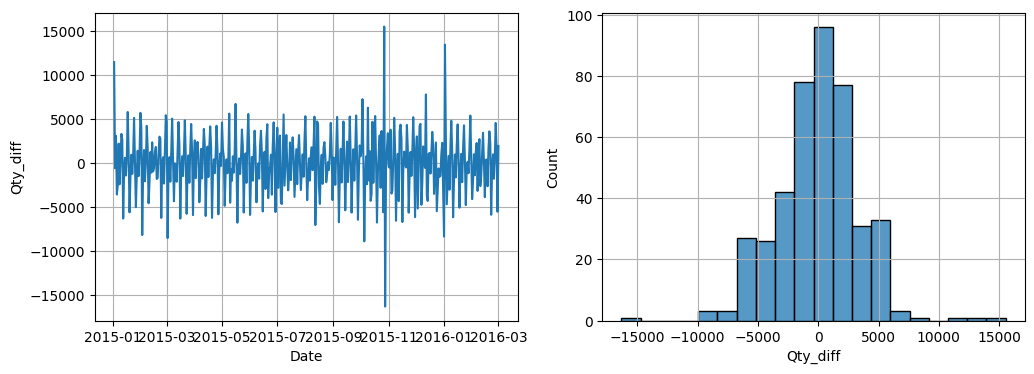

In [76]:
sales_trends_prod2(12, '2015-01-01', '2016-03-01')

,Product_ID,Product_Code,SubCategory,Category,LeadTime,Price
15,42,FM001,Agricultural products,Grocery,2,5


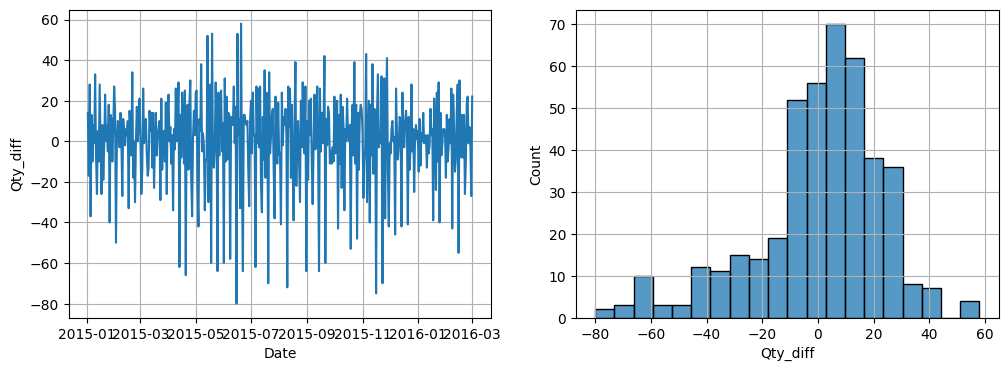

In [77]:
sales_trends_prod2(42, '2015-01-01', '2016-03-01')

In [125]:
def plot_sales_average(Product_ID, freq='6M'):
   """
   특정 제품의 판매량 평균을 그래프로 그리는 함수

   Parameters:
   ----------
   Product_ID : int
       분석할 제품의 ID
   freq : str, default='6M'
       기간 단위 ('M':월별, '3M':분기별, '6M':6개월별, 'Y':연도별)
   """

   # 해당 제품의 데이터만 필터링
   product_sales = sales[sales['Product_ID'] == Product_ID].copy()

   # 날짜를 datetime으로 변환하고 지정된 주기로 그룹화하여 평균 계산
   product_sales['Date'] = pd.to_datetime(product_sales['Date'])
   period_avg = product_sales.groupby(pd.Grouper(key='Date', freq=freq))['Qty'].mean()

   # 그래프 크기 설정
   plt.figure(figsize=(12, 6))

   # 막대 그래프 그리기
   bars = plt.bar(period_avg.index.strftime('%Y.%m'), period_avg.values)

   # 그래프 제목 설정 (주기별로 다르게)
   freq_dict = {'M': 'Monthly', '3M': 'Quarterly', '6M': 'Semi-Annual', 'Y': 'Yearly'}
   title = f'[ID {Product_ID}] {freq_dict.get(freq, "")} Avg Sales Qty'

   # 그래프 꾸미기
   plt.title(title, pad=15, fontsize=20)
   plt.xlabel('Period', fontsize=15)
   plt.ylabel('Average Sales', fontsize=15)

   # x축 레이블 회전
   plt.xticks(rotation=45)

   # y축 범위 설정 (데이터의 최댓값을 기준으로 여유있게 설정)
   plt.ylim(0, period_avg.max() * 1.1)

   # 각 막대 위에 값 표시
   for bar in bars:
       height = bar.get_height()
       plt.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height):,}',  # 천 단위 구분 쉼표 추가
               ha='center', va='bottom')

   # 그리드 추가
   plt.grid(axis='y', linestyle='--', alpha=0.7)

   # 그래프가 잘리지 않도록 레이아웃 조정
   plt.tight_layout()

   # 그래프 표시
   plt.show()

   # 기초 통계량 출력
   print(f"\n[ID {Product_ID}] 기초 통계량:")
   print(f"전체 평균 판매량: {int(product_sales['Qty'].mean()):,}")
   print(f"최소 평균 판매량: {int(period_avg.min()):,} ({period_avg.idxmin().strftime('%Y.%m')})")
   print(f"최대 평균 판매량: {int(period_avg.max()):,} ({period_avg.idxmax().strftime('%Y.%m')})")

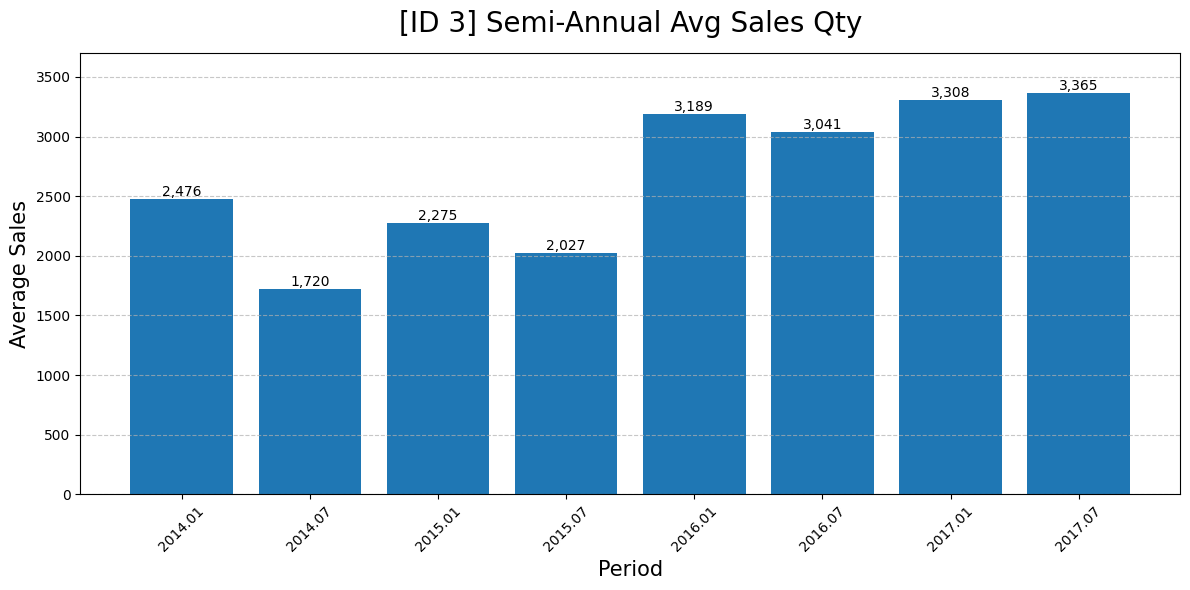


[ID 3] 기초 통계량:
전체 평균 판매량: 2,611
최소 평균 판매량: 1,720 (2014.07)
최대 평균 판매량: 3,365 (2017.07)


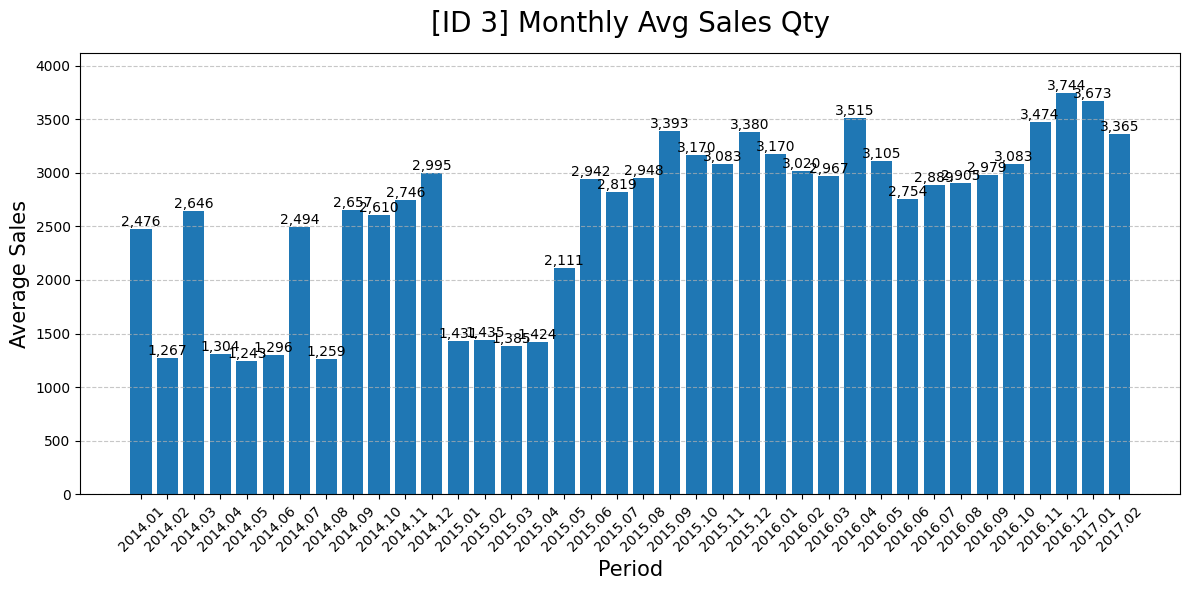


[ID 3] 기초 통계량:
전체 평균 판매량: 2,611
최소 평균 판매량: 1,243 (2014.05)
최대 평균 판매량: 3,744 (2016.12)


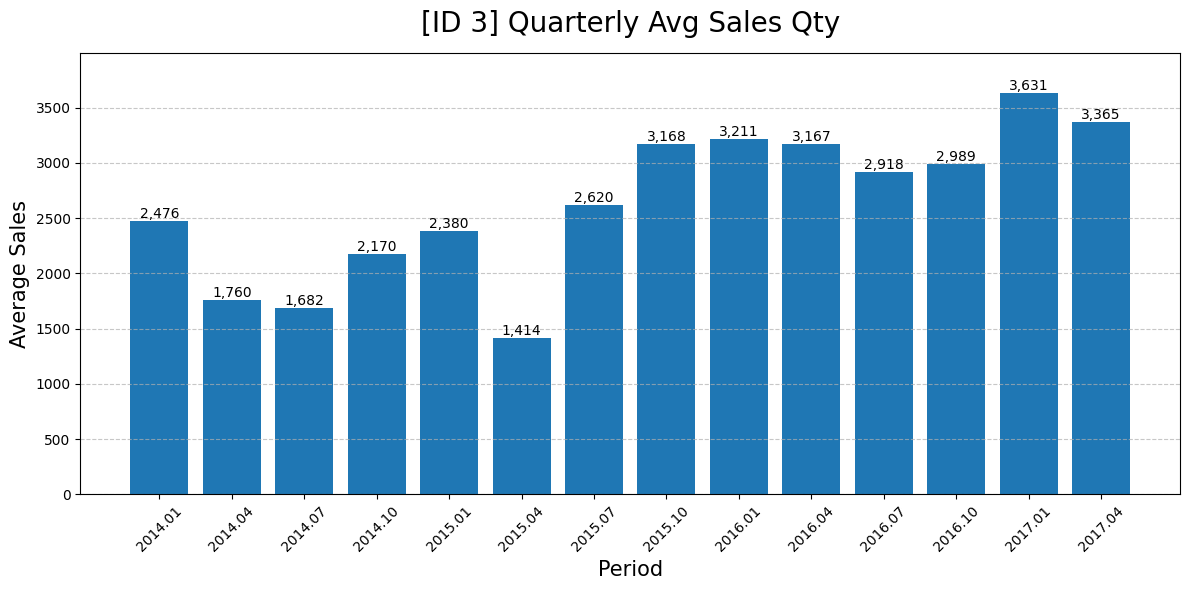


[ID 3] 기초 통계량:
전체 평균 판매량: 2,611
최소 평균 판매량: 1,414 (2015.04)
최대 평균 판매량: 3,631 (2017.01)


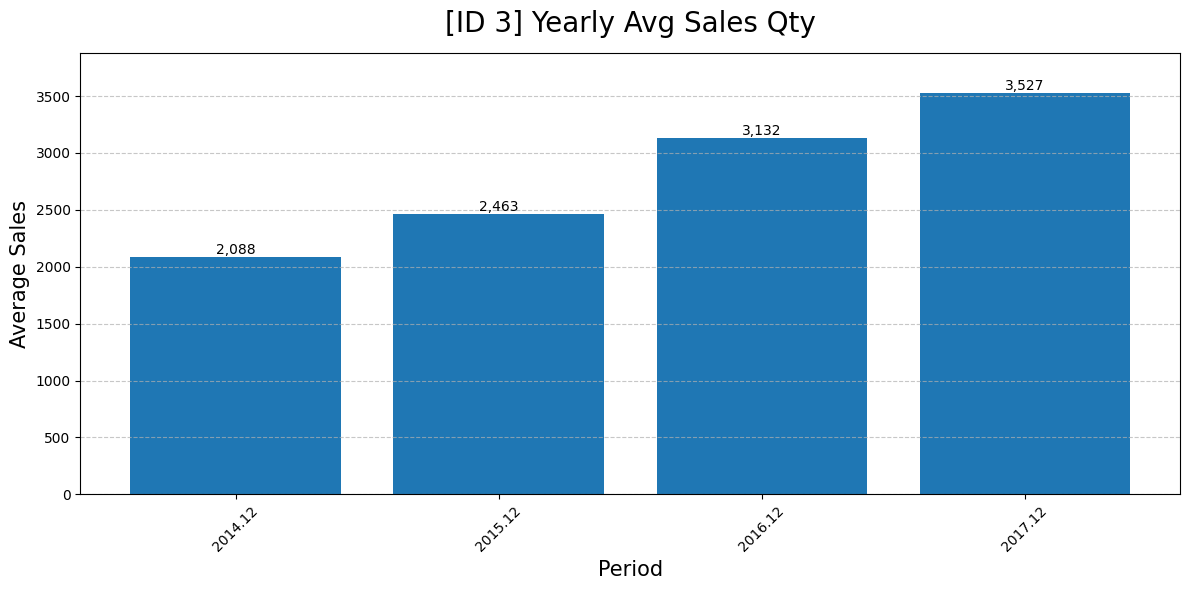


[ID 3] 기초 통계량:
전체 평균 판매량: 2,611
최소 평균 판매량: 2,088 (2014.12)
최대 평균 판매량: 3,527 (2017.12)


In [126]:
# 6개월 단위 평균 그래프
plot_sales_average(3)

# 월별 평균 그래프
plot_sales_average(3, freq='M')

# 분기별 평균 그래프
plot_sales_average(3, freq='3M')

# 연도별 평균 그래프
plot_sales_average(3, freq='Y')

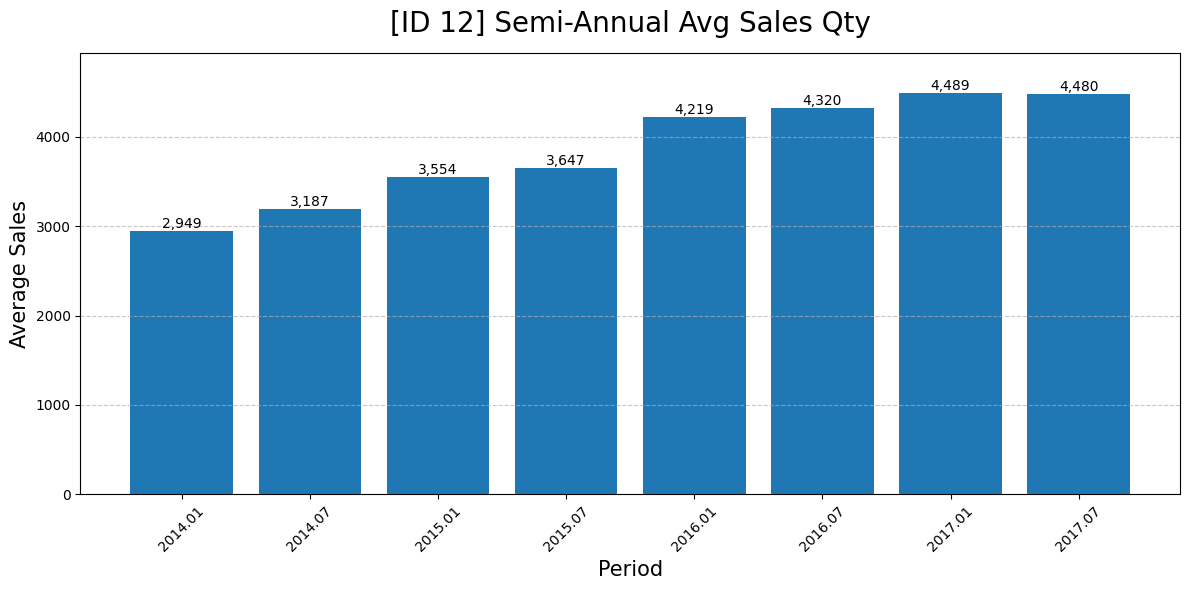


[ID 12] 기초 통계량:
전체 평균 판매량: 3,893
최소 평균 판매량: 2,949 (2014.01)
최대 평균 판매량: 4,489 (2017.01)


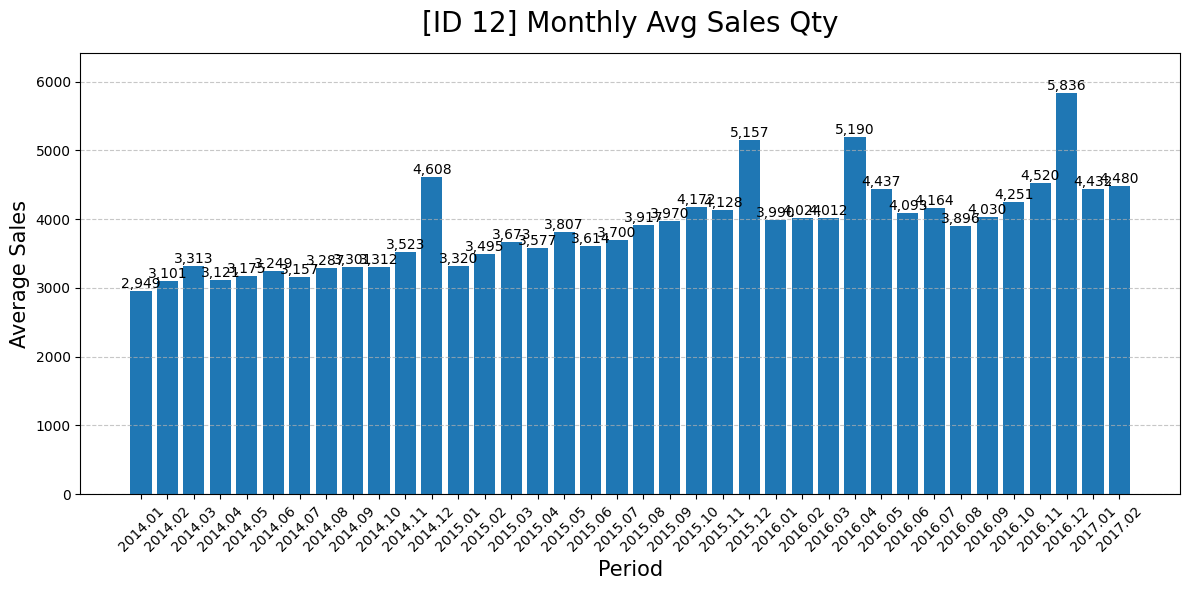


[ID 12] 기초 통계량:
전체 평균 판매량: 3,893
최소 평균 판매량: 2,949 (2014.01)
최대 평균 판매량: 5,836 (2016.12)


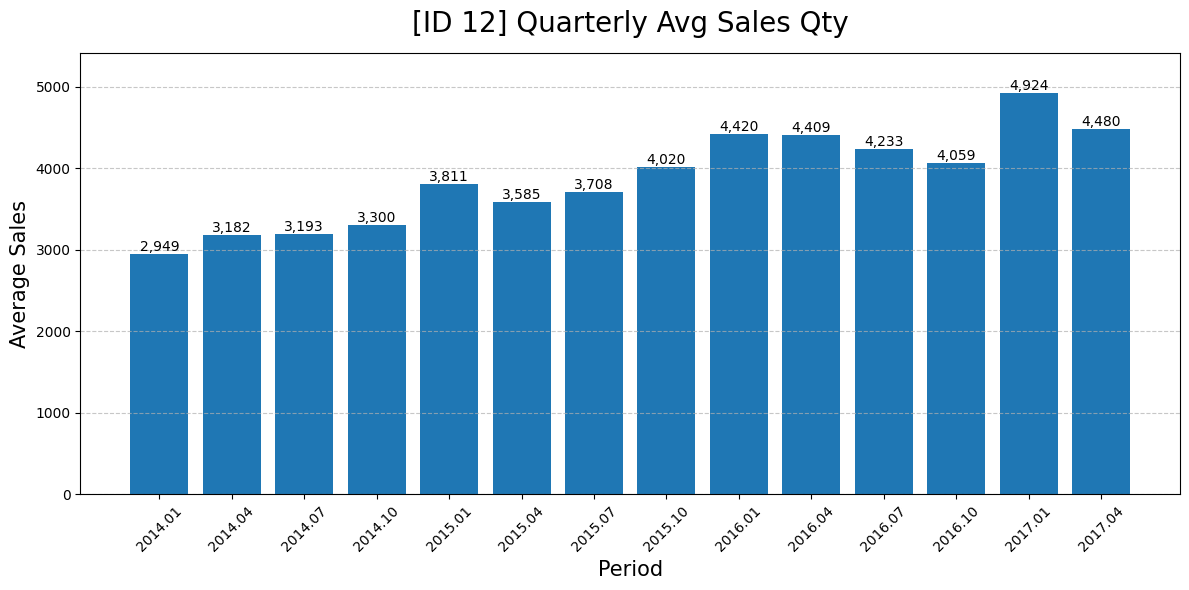


[ID 12] 기초 통계량:
전체 평균 판매량: 3,893
최소 평균 판매량: 2,949 (2014.01)
최대 평균 판매량: 4,924 (2017.01)


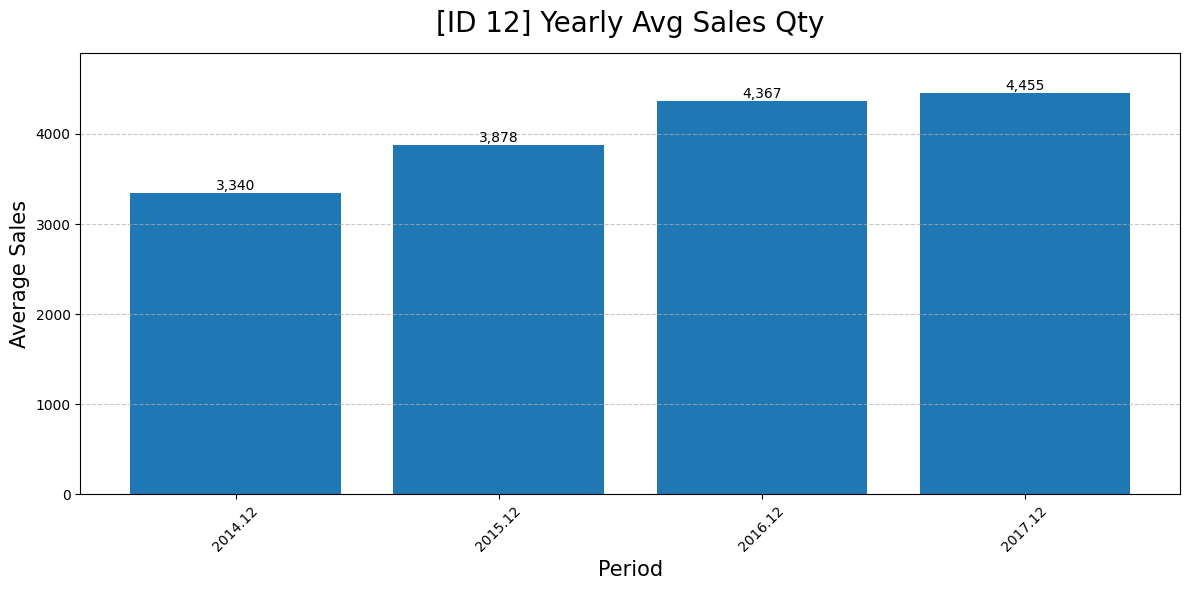


[ID 12] 기초 통계량:
전체 평균 판매량: 3,893
최소 평균 판매량: 3,340 (2014.12)
최대 평균 판매량: 4,455 (2017.12)


In [127]:
# 6개월 단위 평균 그래프
plot_sales_average(12)

# 월별 평균 그래프
plot_sales_average(12, freq='M')

# 분기별 평균 그래프
plot_sales_average(12, freq='3M')

# 연도별 평균 그래프
plot_sales_average(12, freq='Y')

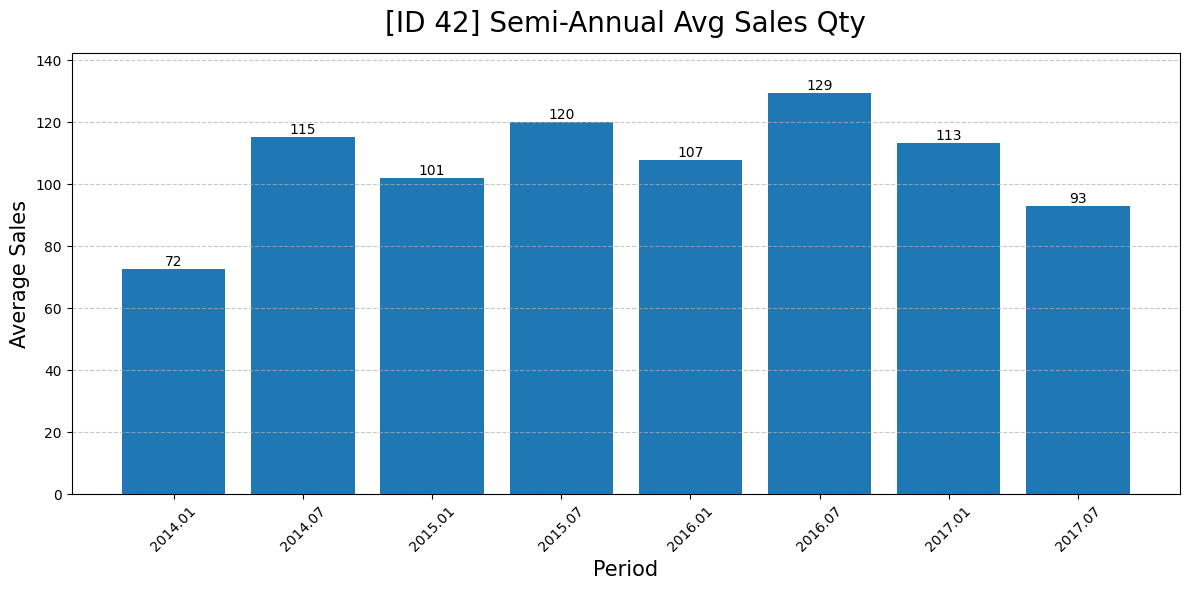


[ID 42] 기초 통계량:
전체 평균 판매량: 112
최소 평균 판매량: 72 (2014.01)
최대 평균 판매량: 129 (2016.07)


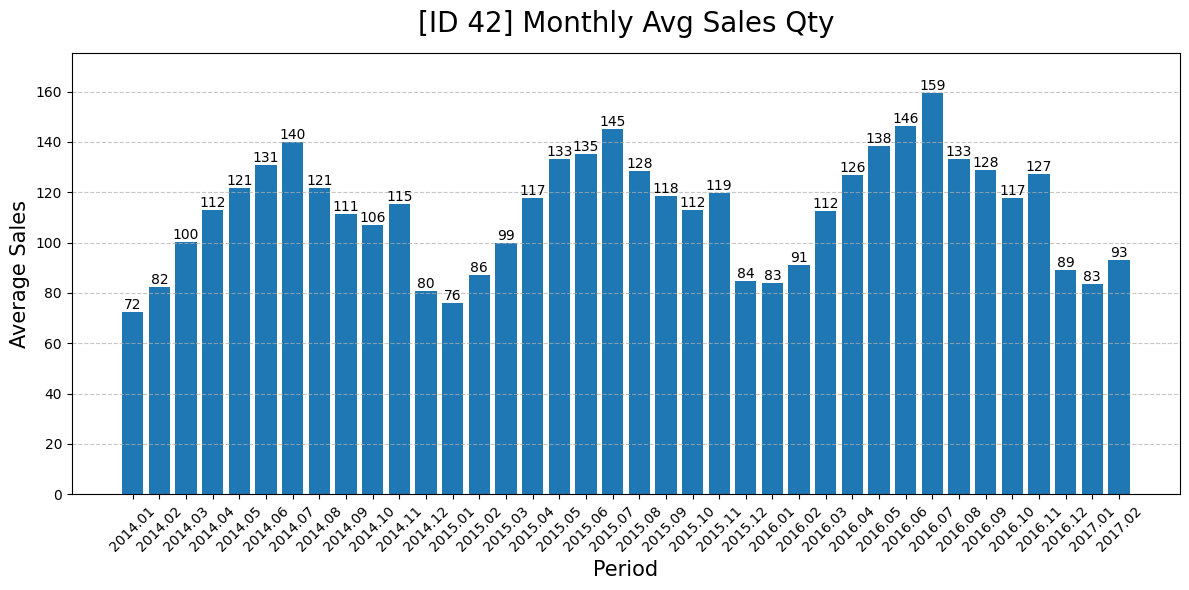


[ID 42] 기초 통계량:
전체 평균 판매량: 112
최소 평균 판매량: 72 (2014.01)
최대 평균 판매량: 159 (2016.07)


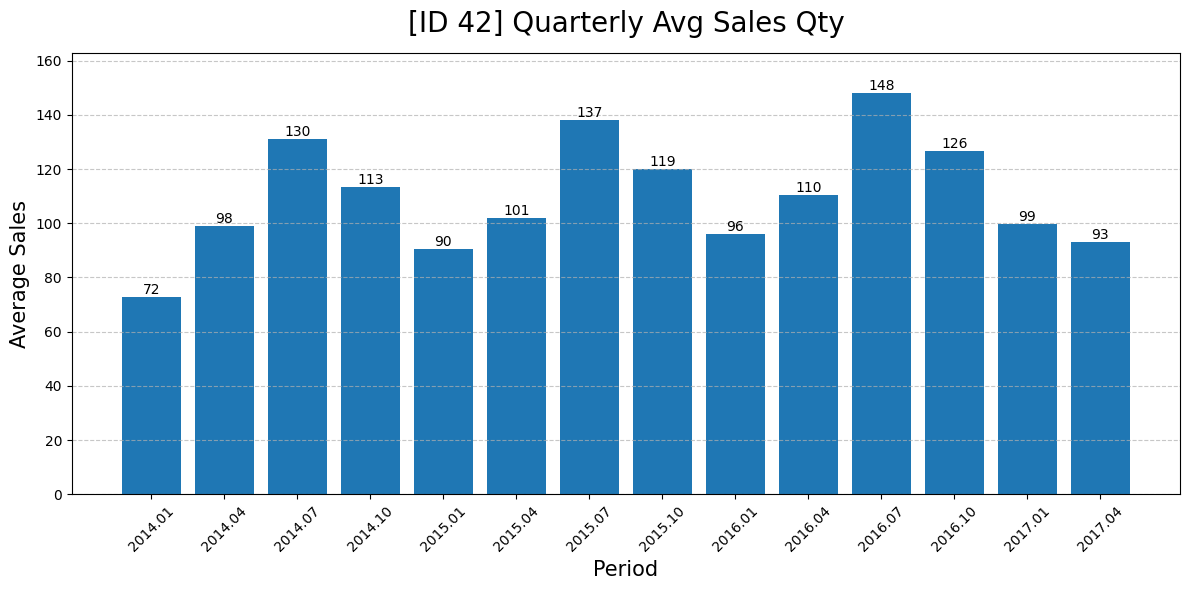


[ID 42] 기초 통계량:
전체 평균 판매량: 112
최소 평균 판매량: 72 (2014.01)
최대 평균 판매량: 148 (2016.07)


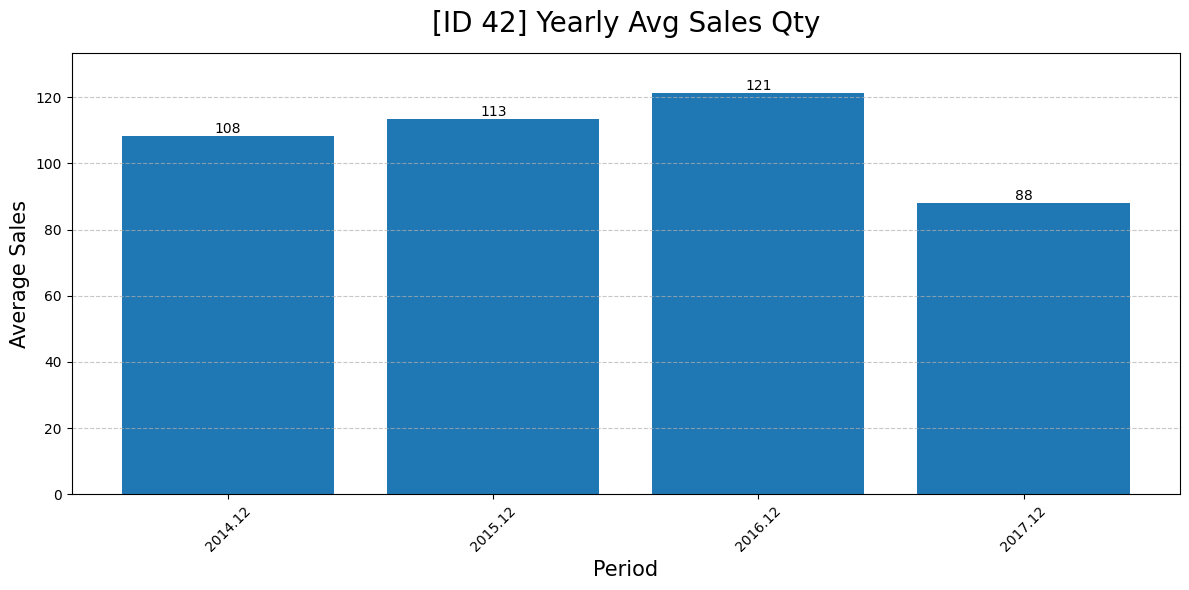


[ID 42] 기초 통계량:
전체 평균 판매량: 112
최소 평균 판매량: 88 (2017.12)
최대 평균 판매량: 121 (2016.12)


In [128]:
# 6개월 단위 평균 그래프
plot_sales_average(42)

# 월별 평균 그래프
plot_sales_average(42, freq='M')

# 분기별 평균 그래프
plot_sales_average(42, freq='3M')

# 연도별 평균 그래프
plot_sales_average(42, freq='Y')

### 2) 요일별 변화량 비교

In [101]:
def data_weekday(Product_ID):
    df = sales.loc[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID)]
    df['Date'] = pd.to_datetime(df['Date'])

    df['Weekday'] = df['Date'].dt.day_name()
    df['Qty_diff'] = df['Qty'].diff()

    # 요일별 평균 판매량 계산
    weekday_avg = df.groupby('Weekday')['Qty'].mean().reindex([
        'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
    ])

    # 시각화
    plt.figure(figsize = (10,3.5))
    plt.subplot(1,2,1)
    sns.barplot(x='Weekday', y = 'Qty', data = df)
    plt.title(f'[ID{Product_ID}] Average Daily Sales by Weekday')
    plt.ylabel('Average Sales')
    plt.xticks(rotation=45)
    plt.grid()

    plt.subplot(1,2,2)
    sns.barplot(x='Weekday', y = 'Qty_diff', data = df)
    plt.title(f'ID{Product_ID}] Change in Sales by Weekday')
    plt.ylabel('Change in Sales')
    plt.xticks(rotation=45)
    plt.grid()

    plt.tight_layout()


    plt.show()

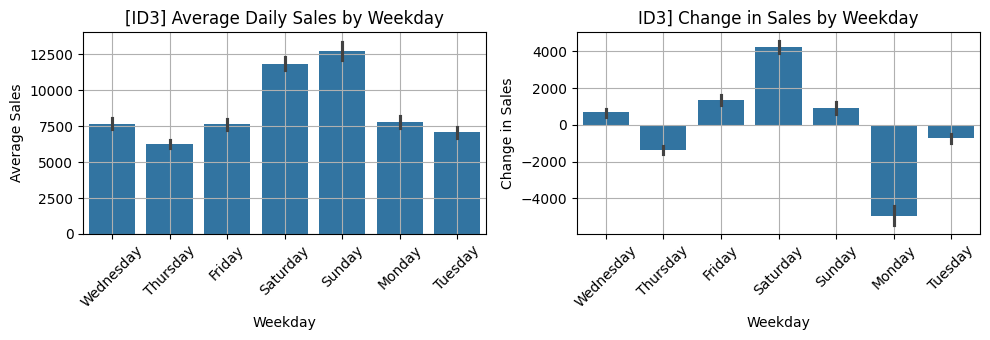

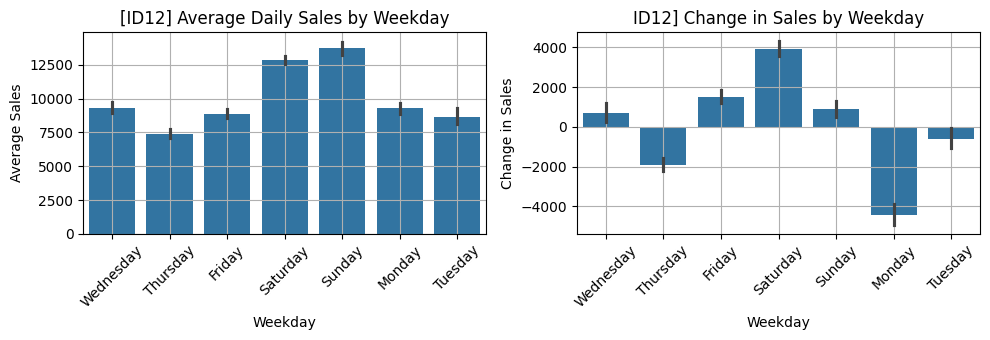

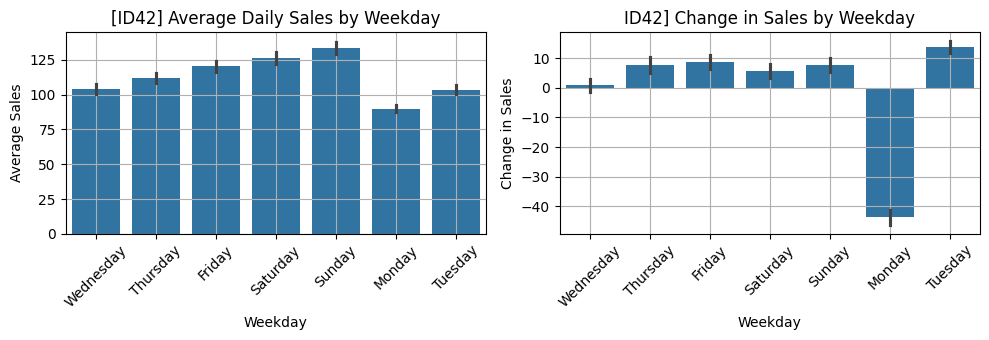

In [102]:
data_weekday(3)
data_weekday(12)
data_weekday(42)

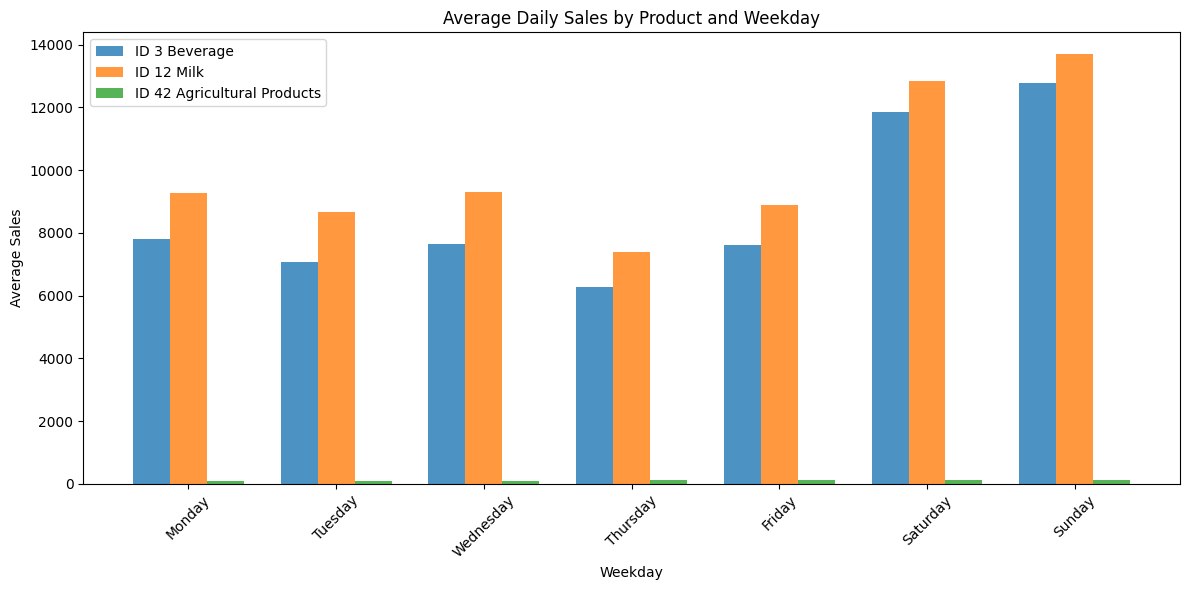

In [84]:
# ID별 데이터 만들기
data = sales.merge(orders, on = ['Date', 'Store_ID'], how = 'left')
data_3 = data[(data['Store_ID']==44)&(data['Product_ID'] == 3)]
data_3 = data_3.drop(columns=['Store_ID']).reset_index(drop = True)

data_12 = data[(data['Store_ID']==44)&(data['Product_ID'] == 12)]
data_12 = data_12.drop(columns=['Store_ID']).reset_index(drop = True)

data_42 = data[(data['Store_ID']==44)&(data['Product_ID'] == 42)]
data_42 = data_42.drop(columns=['Store_ID']).reset_index(drop = True)

# 데이터프레임 합치기
df_combined = pd.concat([data_3, data_12, data_42])

# 날짜 변환 및 요일 추가
df_combined['Date'] = pd.to_datetime(df_combined['Date'])
df_combined['Weekday'] = df_combined['Date'].dt.day_name()

# 제품별, 요일별 평균 판매량 계산
weekday_avg = df_combined.groupby(['Product_ID', 'Weekday'])['Qty'].mean().unstack()

# 요일 순서 지정
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg[weekday_order]

# 시각화
plt.figure(figsize=(12, 6))
x = range(len(weekday_order))
width = 0.25  # 막대 너비

plt.bar(x, weekday_avg.iloc[0], width, label='ID 3 Beverage', alpha=0.8)
plt.bar([i + width for i in x], weekday_avg.iloc[1], width, label='ID 12 Milk', alpha=0.8)
plt.bar([i + width*2 for i in x], weekday_avg.iloc[2], width, label='ID 42 Agricultural Products', alpha=0.8)

plt.xlabel('Weekday')
plt.ylabel('Average Sales')
plt.title('Average Daily Sales by Product and Weekday')
plt.xticks([i + width for i in x], weekday_order, rotation=45)
plt.legend()
plt.tight_layout()

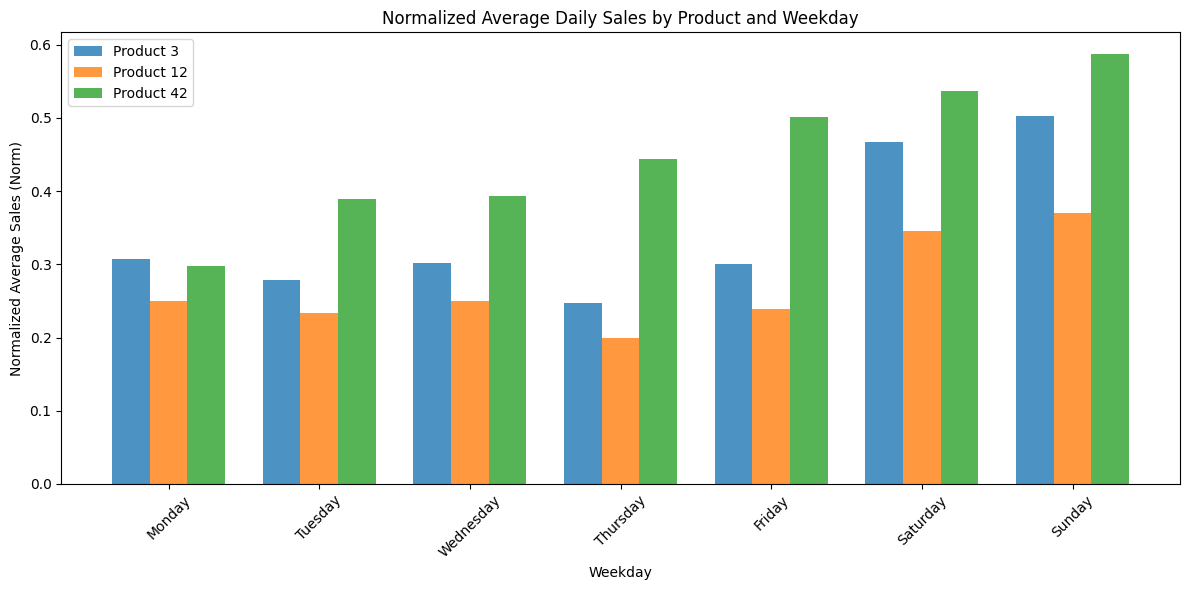


원본 판매량 기초 통계:
             count          mean          std   min     25%     50%       75%  \
Product_ID                                                                      
3           1152.0   8723.729167  3650.526660   0.0  6569.5  8029.5  10320.00   
12          1152.0  10007.207498  3463.547023   0.0  7538.0  8930.0  12031.75   
42          1155.0    112.945455    28.184641  45.0    92.0   112.0    132.00   

                max  
Product_ID           
3           25413.0  
12          37106.0  
42            196.0  


In [85]:
# 각 데이터프레임에 Product_ID 컬럼 추가
data_3['Product_ID'] = 3
data_12['Product_ID'] = 12
data_42['Product_ID'] = 42

# 데이터프레임 합치기
df_combined = pd.concat([data_3, data_12, data_42])

# 날짜 변환 및 요일 추가
df_combined['Date'] = pd.to_datetime(df_combined['Date'])
df_combined['Weekday'] = df_combined['Date'].dt.day_name()

# 제품별로 판매량 표준화
df_combined['Qty_Normalized'] = df_combined.groupby('Product_ID')['Qty'].transform(lambda x: (x - x.min()) / (x.max()-x.min()))

# 제품별, 요일별 평균 정규화된 판매량 계산
weekday_avg = df_combined.groupby(['Product_ID', 'Weekday'])['Qty_Normalized'].mean().unstack()

# 요일 순서 지정
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg[weekday_order]

# 시각화
plt.figure(figsize=(12, 6))
x = range(len(weekday_order))
width = 0.25

plt.bar(x, weekday_avg.iloc[0], width, label='Product 3', alpha=0.8)
plt.bar([i + width for i in x], weekday_avg.iloc[1], width, label='Product 12', alpha=0.8)
plt.bar([i + width*2 for i in x], weekday_avg.iloc[2], width, label='Product 42', alpha=0.8)

plt.xlabel('Weekday')
plt.ylabel('Normalized Average Sales (Norm)')
plt.title('Normalized Average Daily Sales by Product and Weekday')
plt.xticks([i + width for i in x], weekday_order, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 각 제품별 기초 통계량 출력
print("\n원본 판매량 기초 통계:")
print(df_combined.groupby('Product_ID')['Qty'].describe())

### 3) 시계열 데이터 분해

In [70]:
def decomp_plot(Product_ID, sdate, edate, period ) :

    # 시계열 데이터 분해
    temp = sales.loc[(sales['Store_ID'] == 44) & (sales['Product_ID'] == Product_ID) & (sales['Date'].between(sdate, edate))]
    decomp = sm.tsa.seasonal_decompose(temp['Qty'], model = 'additive', period = period)

    # 시계열 분해 결과를 받아서 데이터프레임으로 저장
    result = pd.DataFrame({'observed':decomp.observed, 'trend':decomp.trend, 'seasonal':decomp.seasonal, 'residual':decomp.resid})

    # 4개의 그래프로 나눠서 그리기
    plt.figure(figsize=(15, 8))

    plt.subplot(4,1,1)
    plt.plot(result['observed'])
    plt.ylabel('observed')

    plt.subplot(4,1,2)
    plt.plot(result['trend'])
    plt.ylabel('trend')

    plt.subplot(4,1,3)
    plt.plot(result['seasonal'])
    plt.ylabel('seasonal')

    plt.subplot(4,1,4)
    plt.plot(result['residual'])
    plt.ylabel('residual')
    plt.show()

    return result

In [69]:
sdate = '2014-01-01'
edate = '2017-02-28'
period = 7 #365 #12 #7

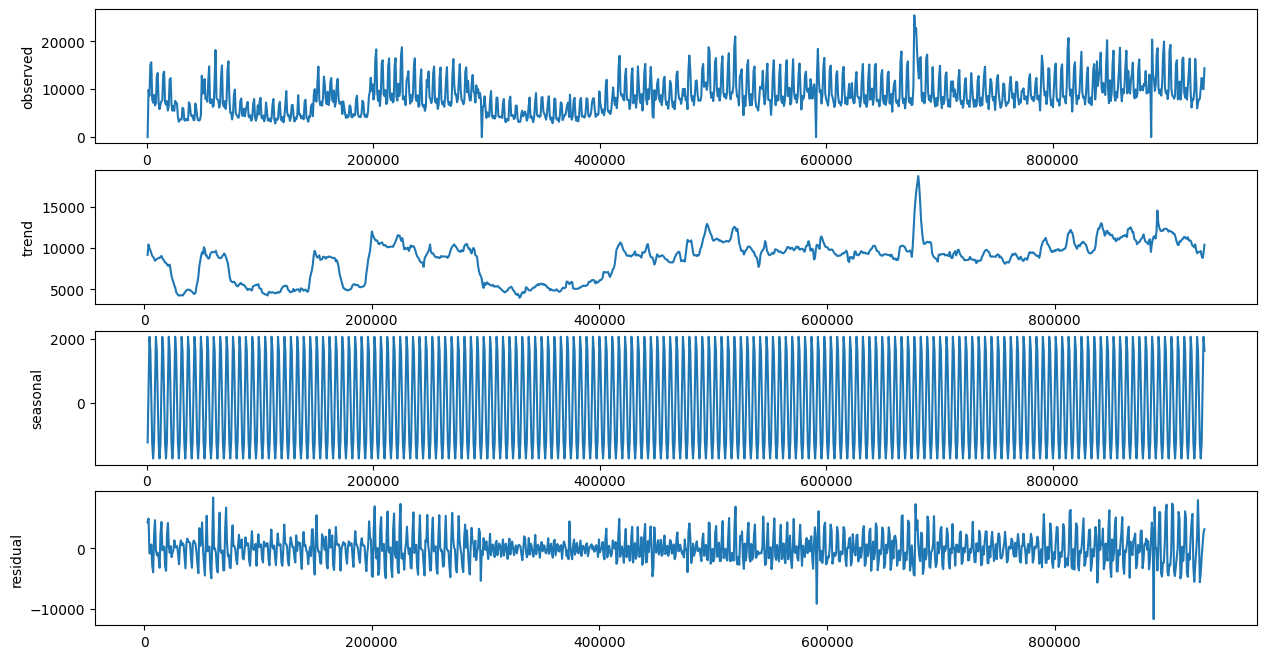

,observed,trend,seasonal,residual
645,0.0,NaN,-1236.581131,NaN
1456,9853.0,NaN,349.377966,NaN
2267,8647.0,NaN,2061.789885,NaN
3078,15153.0,9192.428571,1623.761203,4336.810225
3889,15606.0,10449.571429,203.920611,4952.507960
...,...,...,...,...
930865,10208.0,9390.571429,-1736.521898,2553.950469
931676,12361.0,10418.714286,-1236.581131,3178.866845
932487,10108.0,NaN,349.377966,NaN
933298,10006.0,NaN,2061.789885,NaN


In [71]:
Product_ID = 3
decomp_plot(Product_ID, sdate, edate, period)

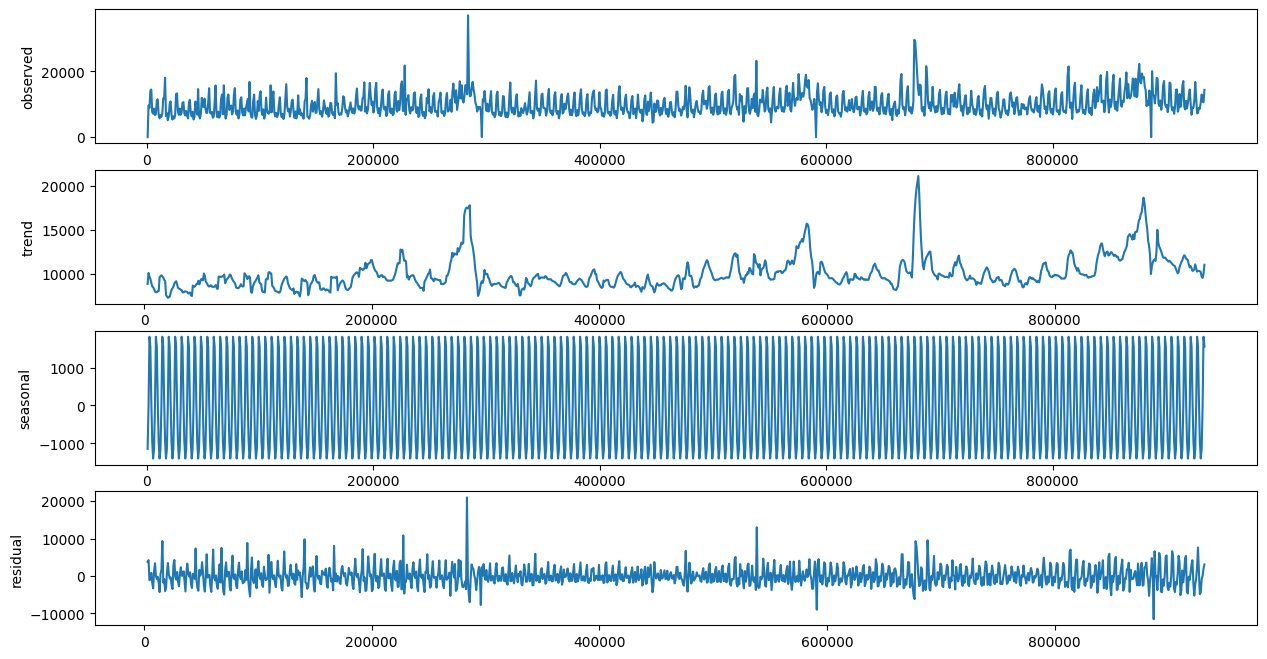

,observed,trend,seasonal,residual
651,0.0,NaN,-1146.541155,NaN
1462,9647.0,NaN,-13.491675,NaN
2273,8879.0,NaN,1813.618754,NaN
3084,14188.0,8848.857143,1556.983945,3782.158912
3895,14490.0,10089.285714,137.196726,4263.517560
...,...,...,...,...
930871,10630.0,10010.428571,-1399.585480,2019.156908
931682,12978.0,11014.142857,-1146.541155,3110.398298
932493,10899.0,NaN,-13.491675,NaN
933304,10618.0,NaN,1813.618754,NaN


In [72]:
Product_ID = 12
decomp_plot(Product_ID, sdate, edate, period)

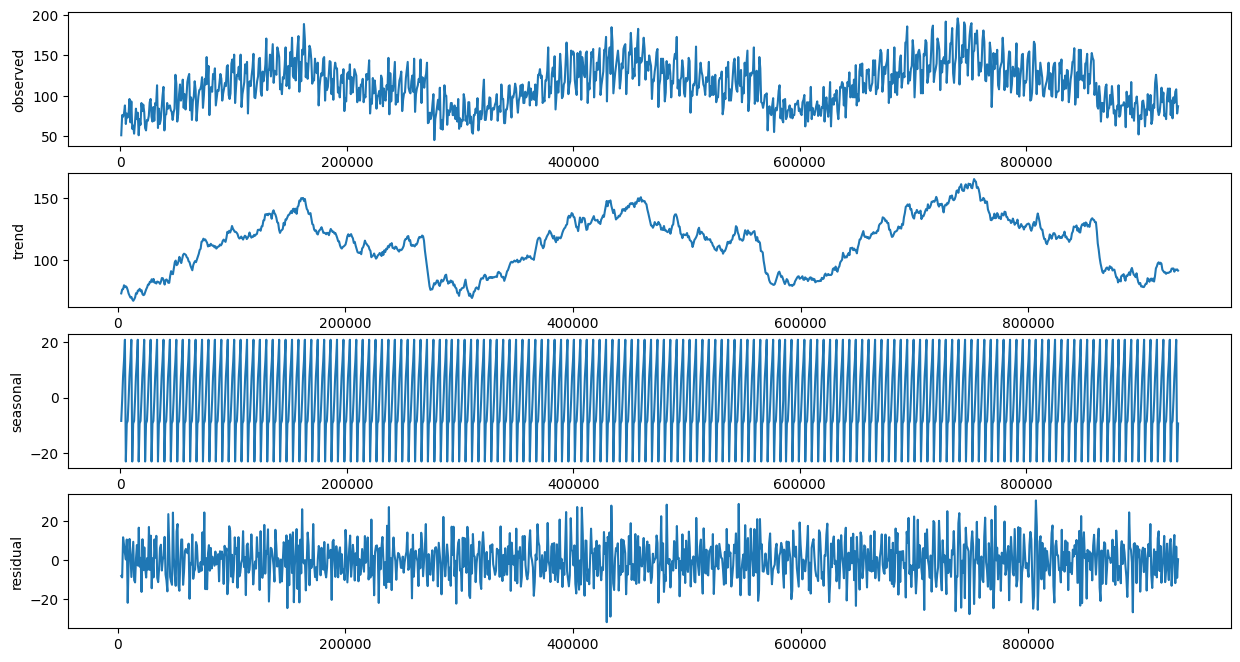

,observed,trend,seasonal,residual
658,51.0,NaN,-8.419806,NaN
1469,76.0,NaN,-0.937227,NaN
2280,74.0,NaN,7.709985,NaN
3091,78.0,72.857143,13.207858,-8.065001
3902,88.0,76.000000,20.790125,-8.790125
...,...,...,...,...
930878,91.0,92.285714,7.709985,-8.995700
931689,105.0,91.285714,13.207858,0.506428
932500,108.0,NaN,20.790125,NaN
933311,78.0,NaN,-23.015624,NaN


In [73]:
Product_ID = 42
decomp_plot(Product_ID, sdate, edate, period)

### 4) 그 외 패턴 찾아보기

**방문 고객수 Top20 데이터 확인**


- 크리스마스 이전 방문 고객수가 가장 많은 것을 확인할 수 있음

In [140]:
# 연도별 데이터 개수 추출
print(data[data['Date'].between('2014-01-01	', '2014-12-31')].shape,
      data[data['Date'].between('2015-01-01	', '2015-12-31')].shape,
      data[data['Date'].between('2016-01-01	', '2016-12-31')].shape,
      data[data['Date'].between('2016-01-01	', '2017-02-28')].shape
      )


(295205, 5) (295205, 5) (296016, 5) (343865, 5)


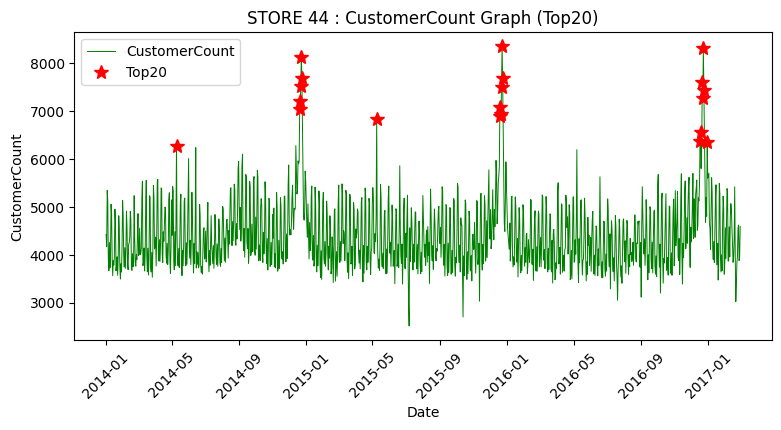

In [141]:
# 방문 고객 수 Top 20
top_customer = df_orders.sort_values(by='CustomerCount', ascending=False).head(20)
top_customer = top_customer.sort_values(by='Date')

plt.figure(figsize=(9,4))

plt.plot(df_orders['Date'], df_orders['CustomerCount'], 'g', label='CustomerCount', linewidth=0.7)
plt.plot(top_customer['Date'], top_customer['CustomerCount'], 'r*', label='Top20', markersize=10)

plt.xlabel('Date')
plt.ylabel('CustomerCount')
plt.title(f"STORE 44 : CustomerCount Graph (Top20)")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [129]:
data_3 = data[(data['Store_ID']==44)&(data['Product_ID'] == 3)].drop(columns=['Store_ID']).reset_index(drop = True)
# 판매량 0인 데이터 확인
data_3[data_3['Qty'] == 0]


,Date,Qty,Product_ID,CustomerCount
0,2014-01-01,0.0,3,NaN
364,2015-01-01,0.0,3,NaN
728,2016-01-01,0.0,3,NaN
1093,2017-01-01,0.0,3,NaN


In [138]:
# ID 12
data_12 = data[(data['Store_ID']==44)&(data['Product_ID'] == 12)].drop(columns=['Store_ID']).reset_index(drop = True)
data_12[data_12['Qty'] == 0]

,Date,Qty,Product_ID,CustomerCount
0,2014-01-01,0.0,12,NaN
364,2015-01-01,0.0,12,NaN
728,2016-01-01,0.0,12,NaN
1093,2017-01-01,0.0,12,NaN


In [139]:
# ID 42
data_42 = data[(data['Store_ID']==44)&(data['Product_ID'] == 42)].drop(columns=['Store_ID']).reset_index(drop = True)
data_42[data_42['Qty'] == 0]

,Date,Qty,Product_ID,CustomerCount


# **3.패턴 정리하기**

* 다양한 탐색을 통해 찾은 시계열 패턴을 적어 봅시다.

**ID 3**

- 주말(토,일)에 판매량 확연히 증가
- 주중에는 상대적으로 낮은 판매량
- 공휴일(예: 1월 1일)은 판매량이 0



- 겨울철(12월)에도 연말 특수로 판매량 증가
- 연간 평균 판매량이 증가하는 추세

- 방문자수와 강한 상관관계

**ID 12**

- 주말(토,일)에 판매량 확연히 증가
- 주중에는 상대적으로 낮은 판매량
- 공휴일(예: 1월 1일)은 판매량이 0


- 연간 평균 판매량이 증가하는 추세

- 방문자수와 강한 상관관계

**ID 42**

- 월별로 일정한 주기적 패턴을 보임
- ID 3, 12에 비해 적은 데이터 범위 45 ~ 196


- 여름철(6-8월)에 판매량이 증가하는 경향
- 겨울철(12-1월)에는 판매량이 다소 감소